# Time Series Analysis and Forecasting of BTC-USDT Prices

## 1. Project Overview

This project performs a complete time series analysis on historical **BTC-USDT** price data obtained from the Binance full history dataset. The objective is to understand the statistical properties of Bitcoin price movements and to build forecasting models using both classical and deep learning–based time series techniques.

**Models Implemented:**
- **ARIMA** — Classical univariate time series model
- **LSTM** — Deep learning model for non-linear temporal patterns
- **Bi-LSTM** — Bidirectional LSTM for capturing both forward and backward temporal dependencies
- **GRU** — Gated Recurrent Unit — lighter recurrent architecture with fewer parameters
- **VAR** — Multivariate model capturing cross-asset dependencies (BTC, ETH, BNB, SOL, ADA)
- **GARCH / EGARCH / GJR-GARCH** — Volatility clustering and risk modeling

**Evaluation Metrics:** MAE, RMSE, MAPE, R², Directional Accuracy, F1-Score, Value-at-Risk

In [1]:
# ============================================================
# Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import os
import glob
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import jarque_bera, probplot, norm

from arch import arch_model

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, Dense, Dropout, Input, Multiply,
                                      Flatten, Activation, RepeatVector,
                                      Permute, Lambda, Bidirectional,
                                      BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, confusion_matrix,
                             precision_score, recall_score, classification_report)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_palette('muted')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Dataset Description

- **Dataset Name:** BTC-USDT.parquet (+ ETH, BNB, SOL, ADA for VAR)
- **Source:** Binance Full History Dataset
- **Variables Used:** Timestamp, Open, High, Low, Close, Volume
- **Target Variable:** Close Price
- **Time Frequency:** Resampled to daily intervals
- **Time Span:** Entire available historical period

In [2]:
# ============================================================
# 2. Load Dataset & Display Raw Structure
# ============================================================
btc_raw = pd.read_parquet('data/BTC-USDT.parquet')
print("Raw BTC-USDT DataFrame:")
print(f"Shape: {btc_raw.shape}")
print(f"Columns: {list(btc_raw.columns)}")
print(f"Dtypes:\n{btc_raw.dtypes}\n")
btc_raw.head()

Raw BTC-USDT DataFrame:
Shape: (2753182, 9)
Columns: ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']
Dtypes:
open                            float32
high                            float32
low                             float32
close                           float32
volume                          float32
quote_asset_volume              float32
number_of_trades                 uint16
taker_buy_base_asset_volume     float32
taker_buy_quote_asset_volume    float32
dtype: object



,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
open_time,,,,,,,,,
2017-08-17 04:00:00,4261.479980,4261.479980,4261.479980,4261.479980,1.775183,7564.906738,3,0.075183,320.390839
2017-08-17 04:01:00,4261.479980,4261.479980,4261.479980,4261.479980,0.000000,0.000000,0,0.000000,0.000000
2017-08-17 04:02:00,4280.560059,4280.560059,4280.560059,4280.560059,0.261074,1117.542969,2,0.261074,1117.542969
2017-08-17 04:03:00,4261.479980,4261.479980,4261.479980,4261.479980,0.012008,51.171852,3,0.012008,51.171852
2017-08-17 04:04:00,4261.479980,4261.479980,4261.479980,4261.479980,0.140796,599.999329,1,0.140796,599.999329


## 3. Problem Statement

The goal of this project is to **model and forecast Bitcoin closing prices** using time series models. Due to high volatility and non-stationarity, cryptocurrency price forecasting presents a challenging and realistic application of time series analysis.

---

## 4. Data Preprocessing

- Convert timestamp to datetime format
- Set timestamp as index and sort chronologically
- Handle missing values (if any)
- Resample data to daily frequency
- Select closing price as the primary time series
- Load all 5 assets for VAR analysis

In [3]:
# ============================================================
# 4. Data Preprocessing
# ============================================================

def load_and_preprocess(filepath):
    """Load a single parquet file and preprocess to daily close prices."""
    df = pd.read_parquet(filepath)
    # If index is already datetime (e.g. open_time), use it directly
    if isinstance(df.index, pd.DatetimeIndex):
        pass
    elif 'open_time' in df.columns:
        df['open_time'] = pd.to_datetime(df['open_time'], unit='ms' if df['open_time'].dtype == 'int64' else None)
        df.set_index('open_time', inplace=True)
    elif 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms' if df['timestamp'].dtype == 'int64' else None)
        df.set_index('timestamp', inplace=True)
    df.sort_index(inplace=True)
    # Resample to daily frequency (last available close price per day)
    daily_close = df['close'].resample('D').last()
    return daily_close

# Load all 5 cryptocurrency assets
asset_files = glob.glob('data/*.parquet')
assets = {}
for f in asset_files:
    name = os.path.basename(f).replace('.parquet', '').replace('-', '_')
    assets[name] = load_and_preprocess(f)

df_multi = pd.DataFrame(assets).dropna()

# Primary BTC series
btc_col = [c for c in df_multi.columns if 'BTC' in c][0]
df_btc = df_multi[btc_col].copy()

# Check for missing values
print("Missing values per asset after preprocessing:")
print(df_multi.isnull().sum())
print(f"\nFinal dataset shape: {df_multi.shape}")
print(f"Date range: {df_multi.index.min().date()} to {df_multi.index.max().date()}")
print(f"Total trading days: {len(df_multi)}")
print(f"Assets: {list(df_multi.columns)}")

Missing values per asset after preprocessing:
ADA_USDT    0
BNB_USDT    0
BTC_USDT    0
ETH_USDT    0
SOL_USDT    0
dtype: int64

Final dataset shape: (828, 5)
Date range: 2020-08-11 to 2022-11-16
Total trading days: 828
Assets: ['ADA_USDT', 'BNB_USDT', 'BTC_USDT', 'ETH_USDT', 'SOL_USDT']


In [4]:
# ============================================================
# Summary Statistics (Section 2 — Table)
# ============================================================
print("=" * 50)
print("BTC-USDT Summary Statistics")
print("=" * 50)
summary = df_btc.describe()
print(f"  Total Records : {len(df_btc)}")
print(f"  Date Range    : {df_btc.index.min().date()} to {df_btc.index.max().date()}")
print(f"  Mean Close    : ${summary['mean']:,.2f}")
print(f"  Std Close     : ${summary['std']:,.2f}")
print(f"  Min Close     : ${summary['min']:,.2f}")
print(f"  Max Close     : ${summary['max']:,.2f}")
print(f"  25th Pctl     : ${summary['25%']:,.2f}")
print(f"  50th Pctl     : ${summary['50%']:,.2f}")
print(f"  75th Pctl     : ${summary['75%']:,.2f}")

BTC-USDT Summary Statistics
  Total Records : 828
  Date Range    : 2020-08-11 to 2022-11-16
  Mean Close    : $34,959.49
  Std Close     : $15,249.79
  Min Close     : $10,126.65
  Max Close     : $67,525.83
  25th Pctl     : $20,292.76
  50th Pctl     : $36,645.81
  75th Pctl     : $46,876.34


---

## 5. Exploratory Data Analysis (EDA)

### 5.1 Time Series Visualization

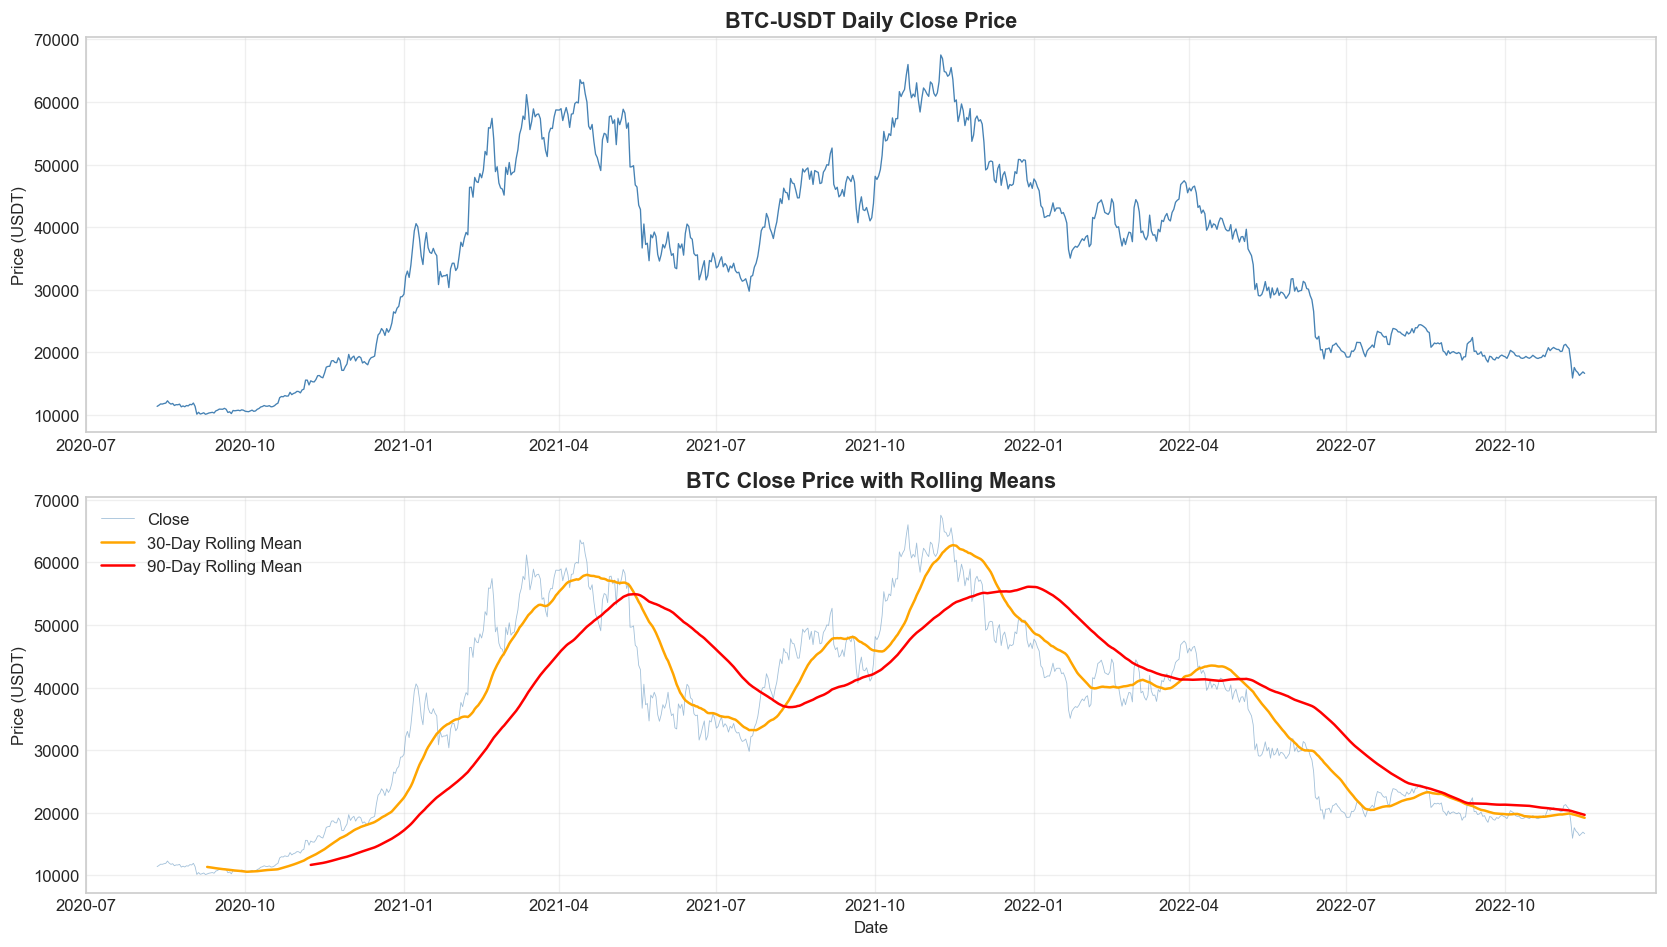

In [5]:
# ============================================================
# 5.1 Time Series Visualization
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Line plot of BTC closing prices
axes[0].plot(df_btc.index, df_btc.values, color='steelblue', linewidth=0.8)
axes[0].set_title('BTC-USDT Daily Close Price', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USDT)')
axes[0].grid(True, alpha=0.3)

# Rolling mean (30-day and 90-day) to observe trend behavior
rolling_30 = df_btc.rolling(window=30).mean()
rolling_90 = df_btc.rolling(window=90).mean()
axes[1].plot(df_btc.index, df_btc.values, color='steelblue', linewidth=0.5, alpha=0.5, label='Close')
axes[1].plot(rolling_30.index, rolling_30.values, color='orange', linewidth=1.5, label='30-Day Rolling Mean')
axes[1].plot(rolling_90.index, rolling_90.values, color='red', linewidth=1.5, label='90-Day Rolling Mean')
axes[1].set_title('BTC Close Price with Rolling Means', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price (USDT)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Stationarity Analysis

We test whether the raw BTC price series is stationary using the **Augmented Dickey-Fuller (ADF) Test**.

- **Null hypothesis (H₀):** The series has a unit root (non-stationary)
- **If p-value ≤ 0.05:** Reject H₀ → series is stationary
- **If p-value > 0.05:** Fail to reject H₀ → series is non-stationary

In [6]:
# ============================================================
# 5.2 Stationarity Analysis — ADF Test on Raw Prices
# ============================================================
def adf_test(series, name='Series'):
    """Perform Augmented Dickey-Fuller test and print results."""
    result = adfuller(series.dropna(), autolag='AIC')
    stat, p_value, lags, nobs = result[0], result[1], result[2], result[3]
    crit = result[4]
    status = "✓ STATIONARY" if p_value <= 0.05 else "✗ NON-STATIONARY"
    print(f"ADF Test — {name}")
    print(f"  Test Statistic : {stat:.4f}")
    print(f"  p-value        : {p_value:.6f}")
    print(f"  Lags Used      : {lags}")
    print(f"  Observations   : {nobs}")
    print(f"  Critical Values: 1%={crit['1%']:.4f}, 5%={crit['5%']:.4f}, 10%={crit['10%']:.4f}")
    print(f"  Result         : {status}\n")
    return p_value

print("=" * 60)
p_raw = adf_test(df_btc, 'BTC Close Price (Raw)')

ADF Test — BTC Close Price (Raw)
  Test Statistic : -1.5501
  p-value        : 0.508590
  Lags Used      : 0
  Observations   : 827
  Critical Values: 1%=-3.4383, 5%=-2.8650, 10%=-2.5686
  Result         : ✗ NON-STATIONARY



### 5.3 Differencing

Since raw BTC prices are non-stationary, we apply **first-order differencing** to remove the trend and then re-test for stationarity.

ADF Test — BTC Close Price (1st Difference)
  Test Statistic : -29.7751
  p-value        : 0.000000
  Lags Used      : 0
  Observations   : 826
  Critical Values: 1%=-3.4383, 5%=-2.8650, 10%=-2.5686
  Result         : ✓ STATIONARY



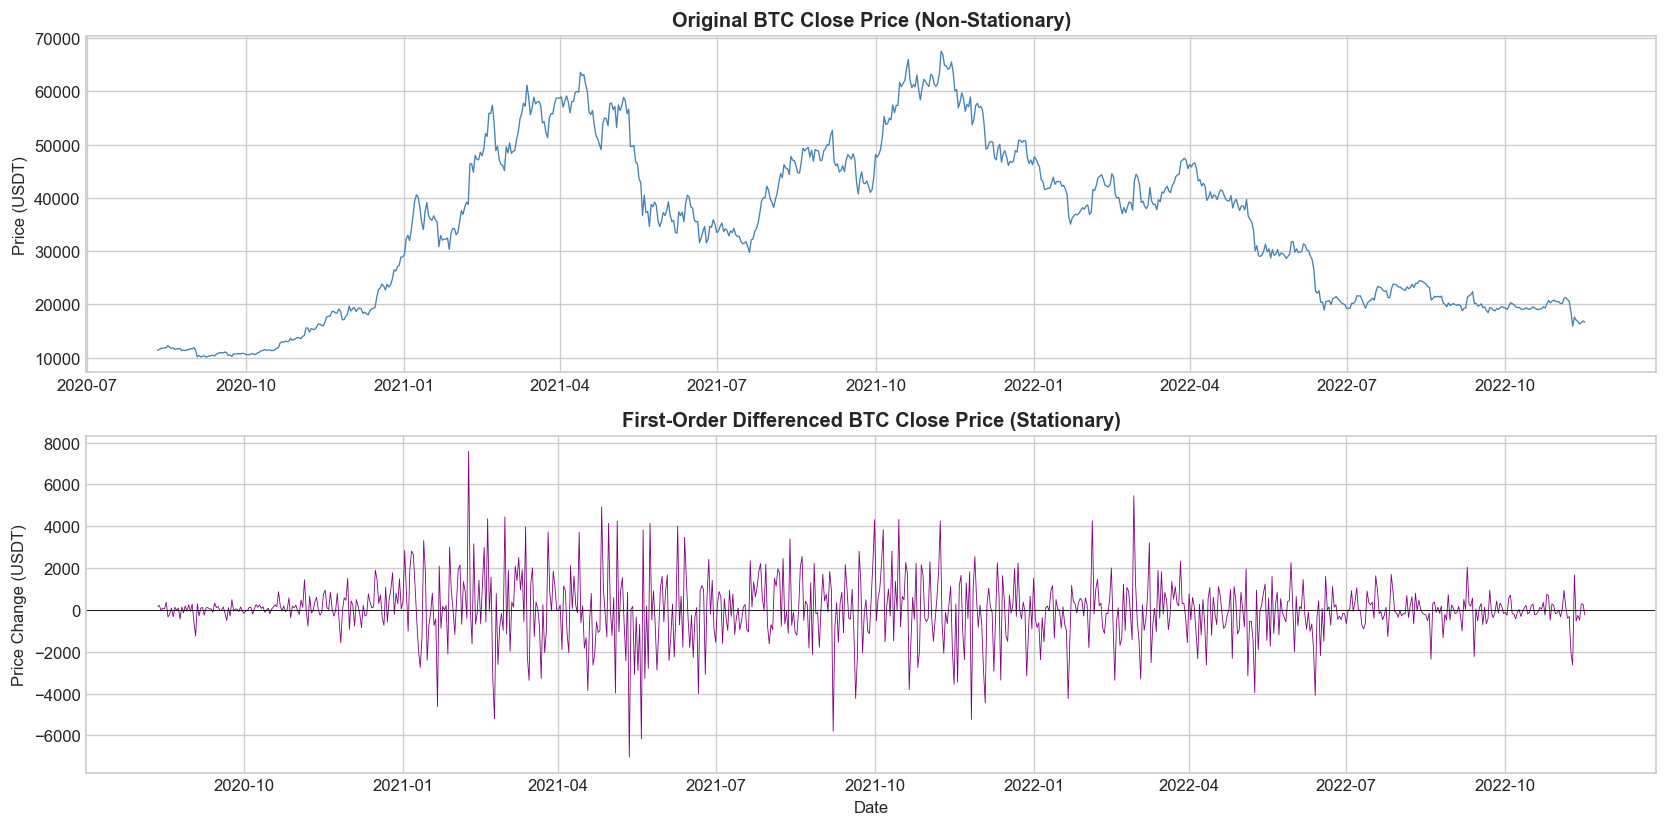

In [7]:
# ============================================================
# 5.3 Differencing & Re-testing Stationarity
# ============================================================
df_btc_diff = df_btc.diff().dropna()

p_diff = adf_test(df_btc_diff, 'BTC Close Price (1st Difference)')

# Visualize original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df_btc.index, df_btc.values, color='steelblue', linewidth=0.8)
axes[0].set_title('Original BTC Close Price (Non-Stationary)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USDT)')

axes[1].plot(df_btc_diff.index, df_btc_diff.values, color='purple', linewidth=0.5)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('First-Order Differenced BTC Close Price (Stationary)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price Change (USDT)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

### 5.4 Returns Distribution Analysis

Compute daily percentage returns for all assets to prepare for VAR and GARCH modeling.

Daily Returns Summary (%):
       ADA_USDT  BNB_USDT  BTC_USDT  ETH_USDT  SOL_USDT
count  827.0000  827.0000  827.0000  827.0000  827.0000
mean     0.2866    0.4803    0.1176    0.2716    0.4900
std      6.0539    6.0326    3.7823    5.1182    7.9357
min    -26.8167  -34.0789  -15.3798  -27.7372  -42.2477
25%     -2.9861   -2.0628   -1.7703   -2.4963   -3.6490
50%      0.0641    0.1947    0.0982    0.3281    0.0155
75%      2.9233    2.9708    1.9377    3.0946    4.1335
max     33.1680   70.3021   19.5361   26.3329   45.8712

BTC Returns — Skewness: 0.0147, Kurtosis: 2.5181


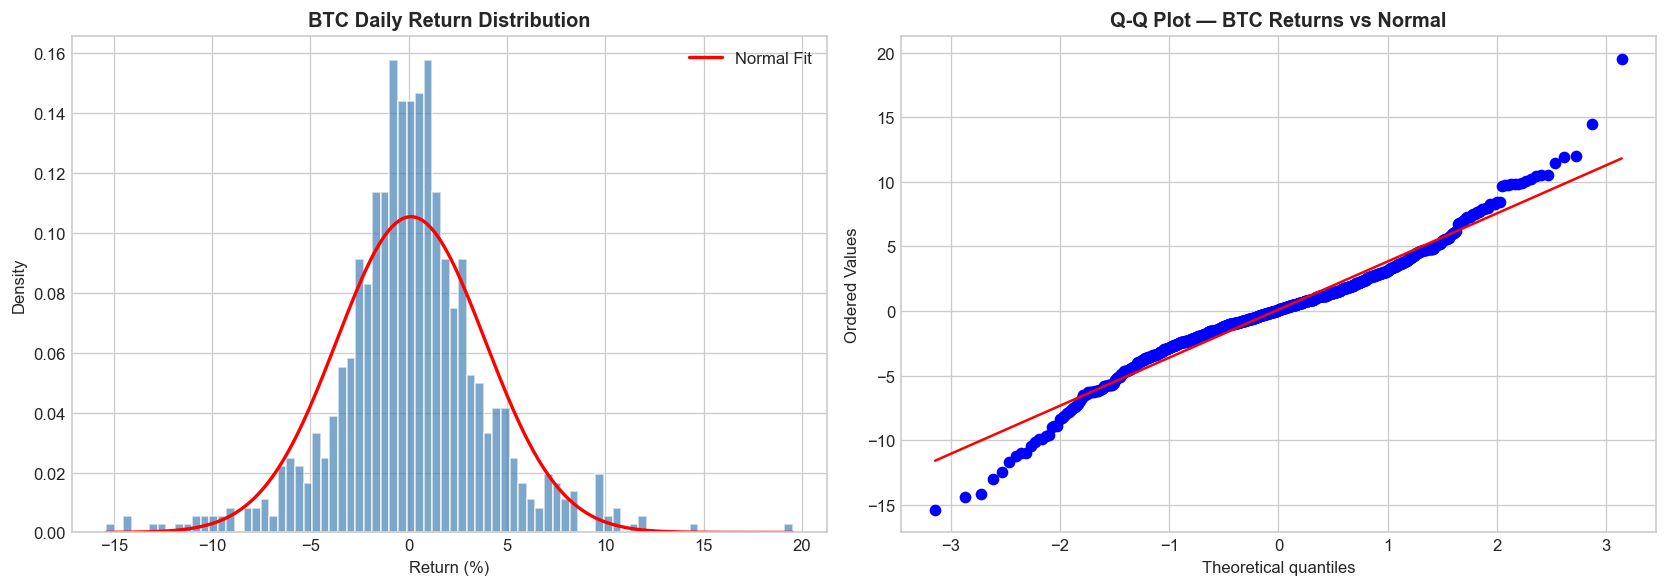

In [8]:
# ============================================================
# 5.4 Returns Distribution Analysis
# ============================================================
# Compute daily percentage returns for all assets
df_returns = df_multi.pct_change().dropna() * 100  # in percent
btc_returns_series = df_returns[btc_col]

print("Daily Returns Summary (%):")
print(df_returns.describe().round(4))
print(f"\nBTC Returns — Skewness: {btc_returns_series.skew():.4f}, Kurtosis: {btc_returns_series.kurtosis():.4f}")

# Return distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal overlay
axes[0].hist(btc_returns_series, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
x_r = np.linspace(btc_returns_series.min(), btc_returns_series.max(), 200)
axes[0].plot(x_r, norm.pdf(x_r, btc_returns_series.mean(), btc_returns_series.std()), 'r-', linewidth=2, label='Normal Fit')
axes[0].set_title('BTC Daily Return Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q plot
probplot(btc_returns_series, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — BTC Returns vs Normal', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 6. Autocorrelation Analysis

### 6.1 ACF & 6.2 PACF

The ACF and PACF plots of the **stationary (differenced)** series are used to guide ARIMA parameter selection:
- **ACF** — identifies the MA order `q` (significant lags before cutoff)
- **PACF** — identifies the AR order `p` (significant lags before cutoff)

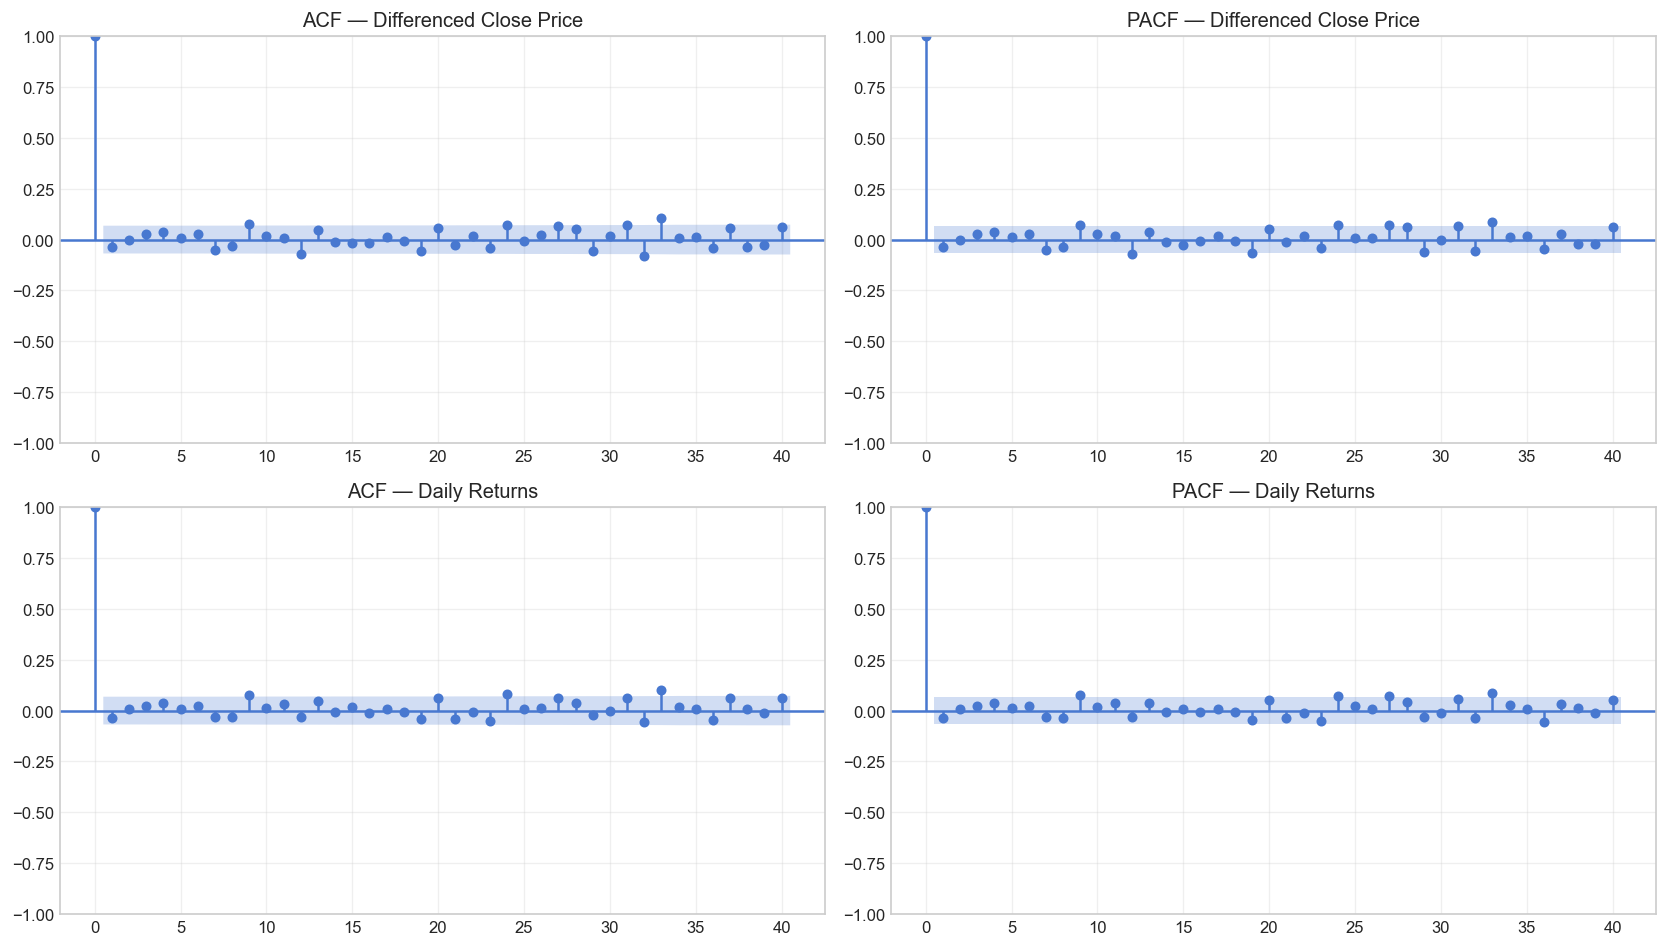

Interpretation:
• Significant spikes in PACF suggest AR terms (p)
• Significant spikes in ACF suggest MA terms (q)
• These plots guide the selection of ARIMA(p,d,q) parameters


In [9]:
# ============================================================
# 6. Autocorrelation Analysis — ACF & PACF
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF of differenced series
plot_acf(df_btc_diff, lags=40, ax=axes[0, 0], title='ACF — Differenced Close Price')
# PACF of differenced series
plot_pacf(df_btc_diff, lags=40, ax=axes[0, 1], title='PACF — Differenced Close Price', method='ywm')

# ACF of returns
plot_acf(btc_returns_series, lags=40, ax=axes[1, 0], title='ACF — Daily Returns')
# PACF of returns
plot_pacf(btc_returns_series, lags=40, ax=axes[1, 1], title='PACF — Daily Returns', method='ywm')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("• Significant spikes in PACF suggest AR terms (p)")
print("• Significant spikes in ACF suggest MA terms (q)")
print("• These plots guide the selection of ARIMA(p,d,q) parameters")

---

## 7. Train–Test Split

- Chronological split to preserve temporal order (80% train / 20% test)
- No shuffling applied
- **ARIMA and LSTM** use the price-level split directly
- **VAR and GARCH** apply the same date-based split on daily returns (not raw prices)

Split Date: 2022-06-04
Train (prices): 662 days (2020-08-11 → 2022-06-03)
Test  (prices): 166 days (2022-06-04 → 2022-11-16)
Train (returns): 662 days
Test  (returns): 165 days


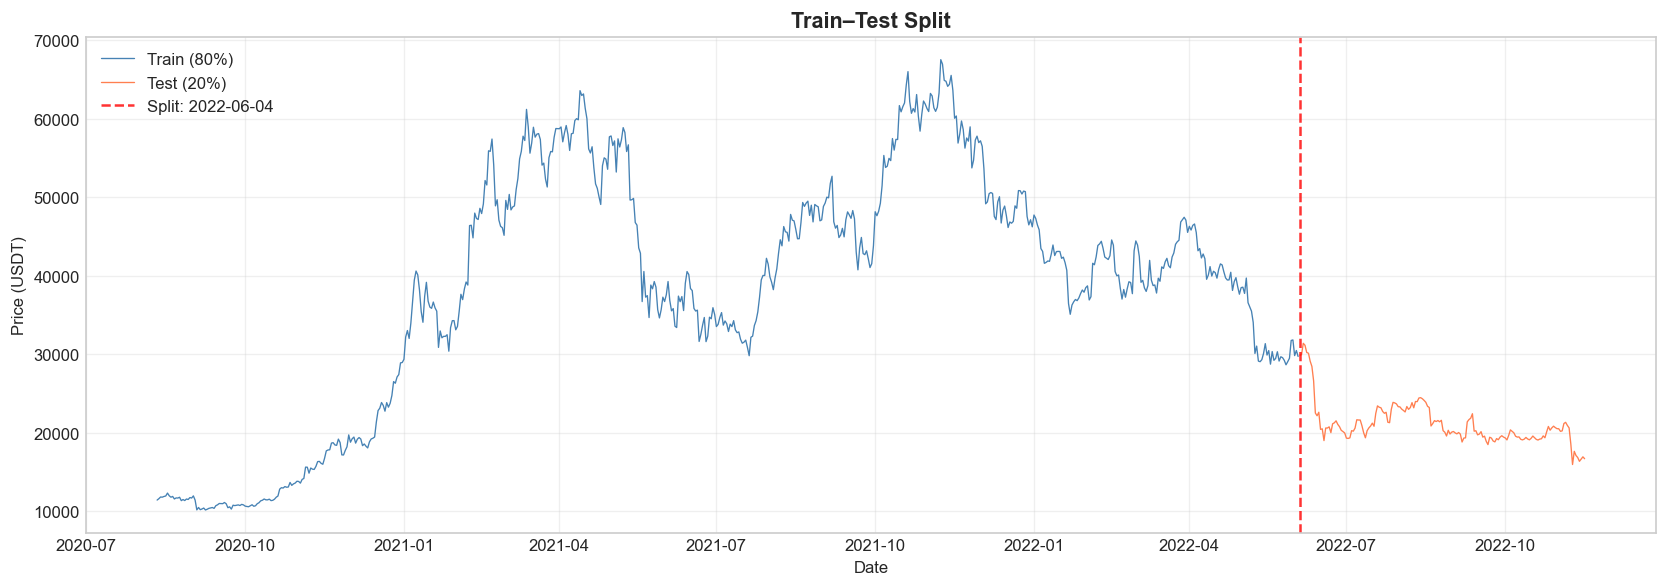

In [10]:
# ============================================================
# 7. Train–Test Split (80/20 Chronological)
# ============================================================
train_size = int(len(df_btc) * 0.8)
split_date = df_btc.index[train_size]

# Price-level split (for ARIMA and LSTM)
train_price = df_btc[:train_size]
test_price = df_btc[train_size:]

# Returns-level split (for VAR and GARCH)
train_returns = df_returns[:train_size]
test_returns = df_returns[train_size:]

print(f"Split Date: {split_date.date()}")
print(f"Train (prices): {len(train_price)} days ({train_price.index.min().date()} → {train_price.index.max().date()})")
print(f"Test  (prices): {len(test_price)} days ({test_price.index.min().date()} → {test_price.index.max().date()})")
print(f"Train (returns): {len(train_returns)} days")
print(f"Test  (returns): {len(test_returns)} days")

# Visualize split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_price.index, train_price.values, color='steelblue', linewidth=0.8, label='Train (80%)')
ax.plot(test_price.index, test_price.values, color='coral', linewidth=0.8, label='Test (20%)')
ax.axvline(x=split_date, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Split: {split_date.date()}')
ax.set_title('Train–Test Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USDT)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 8. ARIMA Model Implementation

### 8.1 Model Selection

We perform a grid search over `(p, d, q)` parameters with `d=1` (based on first-order differencing) and select the optimal model using AIC.

In [11]:
# ============================================================
# 8.1 ARIMA Model Selection — Grid Search
# ============================================================
arima_results = []
d = 1  # based on first-order differencing

for p in range(0, 5):
    for q in range(0, 5):
        try:
            model = ARIMA(train_price, order=(p, d, q))
            fitted = model.fit()
            arima_results.append({
                'p': p, 'd': d, 'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic
            })
        except:
            continue

arima_search_df = pd.DataFrame(arima_results).sort_values('AIC')
print("Top 10 ARIMA Models by AIC:")
print(arima_search_df.head(10).to_string(index=False))

best = arima_search_df.iloc[0]
p_best, d_best, q_best = int(best['p']), int(best['d']), int(best['q'])
print(f"\n→ Best ARIMA: ({p_best},{d_best},{q_best}) — AIC: {best['AIC']:.2f}, BIC: {best['BIC']:.2f}")

Top 10 ARIMA Models by AIC:
 p  d  q          AIC          BIC
 0  1  0 11620.143645 11624.637399
 2  1  2 11620.855401 11643.324170
 1  1  0 11620.983426 11629.970934
 0  1  1 11620.984446 11629.971954
 2  1  4 11622.206465 11653.662742
 2  1  3 11622.843022 11649.805545
 2  1  0 11622.959537 11636.440799
 1  1  1 11622.983158 11636.464419
 0  1  2 11623.014768 11636.496029
 3  1  4 11623.100272 11659.050303

→ Best ARIMA: (0,1,0) — AIC: 11620.14, BIC: 11624.64


### 8.2 Model Fitting & 8.3 Forecasting and Evaluation

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:               BTC_USDT   No. Observations:                  662
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -5809.072
Date:                Thu, 05 Mar 2026   AIC                          11620.144
Time:                        20:28:45   BIC                          11624.637
Sample:                    08-11-2020   HQIC                         11621.885
                         - 06-03-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2.514e+06   9.09e+04     27.660      0.000    2.34e+06    2.69e+06
Ljung-Box (L1) (Q):                   1.28   Jarque-Bera (JB):               190.81
Prob(Q):                  

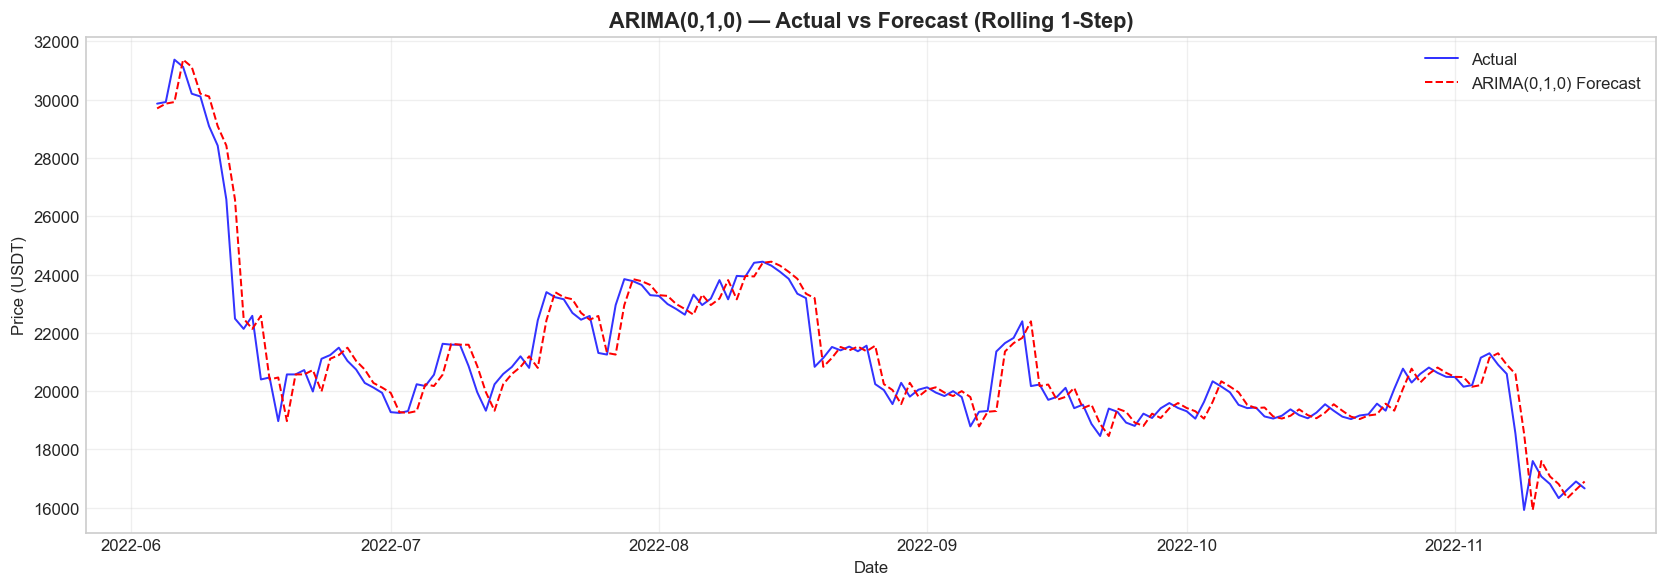

In [12]:
# ============================================================
# 8.2 Fit ARIMA & 8.3 Forecast and Evaluate (Rolling One-Step-Ahead)
# ============================================================
arima_model = ARIMA(train_price, order=(p_best, d_best, q_best))
arima_fitted = arima_model.fit()

print("ARIMA Model Summary:")
print(arima_fitted.summary())

# Rolling one-step-ahead forecast (more realistic evaluation)
print(f"\nRunning rolling one-step-ahead ARIMA({p_best},{d_best},{q_best}) forecast...")
arima_forecast_vals = []
history = list(train_price.values)
for t in range(len(test_price)):
    model_temp = ARIMA(history, order=(p_best, d_best, q_best))
    fit_temp = model_temp.fit()
    yhat = fit_temp.forecast(steps=1)[0]
    arima_forecast_vals.append(yhat)
    history.append(test_price.values[t])  # expand with actual observation

arima_forecast = pd.Series(arima_forecast_vals, index=test_price.index)

# Evaluation metrics
arima_mae = mean_absolute_error(test_price, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test_price, arima_forecast))
arima_mape = np.mean(np.abs((test_price.values - arima_forecast.values) / test_price.values)) * 100
arima_r2 = r2_score(test_price, arima_forecast)

# Directional accuracy
arima_actual_dir = (test_price.diff().dropna() > 0).astype(int).values
arima_pred_dir = (arima_forecast.diff().dropna() > 0).astype(int).values
min_len_arima = min(len(arima_actual_dir), len(arima_pred_dir))
arima_dir_acc = accuracy_score(arima_actual_dir[:min_len_arima], arima_pred_dir[:min_len_arima]) * 100
arima_f1 = f1_score(arima_actual_dir[:min_len_arima], arima_pred_dir[:min_len_arima], zero_division=0) * 100

print(f"\nARIMA({p_best},{d_best},{q_best}) Rolling Forecast Results:")
print(f"  MAE  : ${arima_mae:,.2f}")
print(f"  RMSE : ${arima_rmse:,.2f}")
print(f"  MAPE : {arima_mape:.2f}%")
print(f"  R²   : {arima_r2:.4f}")
print(f"  Directional Accuracy: {arima_dir_acc:.1f}%")
print(f"  F1 Score: {arima_f1:.1f}%")

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_price.index, test_price.values, 'b-', linewidth=1.2, label='Actual', alpha=0.8)
ax.plot(arima_forecast.index, arima_forecast.values, 'r--', linewidth=1.2, label=f'ARIMA({p_best},{d_best},{q_best}) Forecast')
ax.set_title(f'ARIMA({p_best},{d_best},{q_best}) — Actual vs Forecast (Rolling 1-Step)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USDT)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 Residual Diagnostics

We check ARIMA residuals for:
- **Remaining autocorrelation** (ACF plot + Ljung-Box test)
- **Heteroskedasticity** (ARCH effect test) — if present, this motivates using GARCH

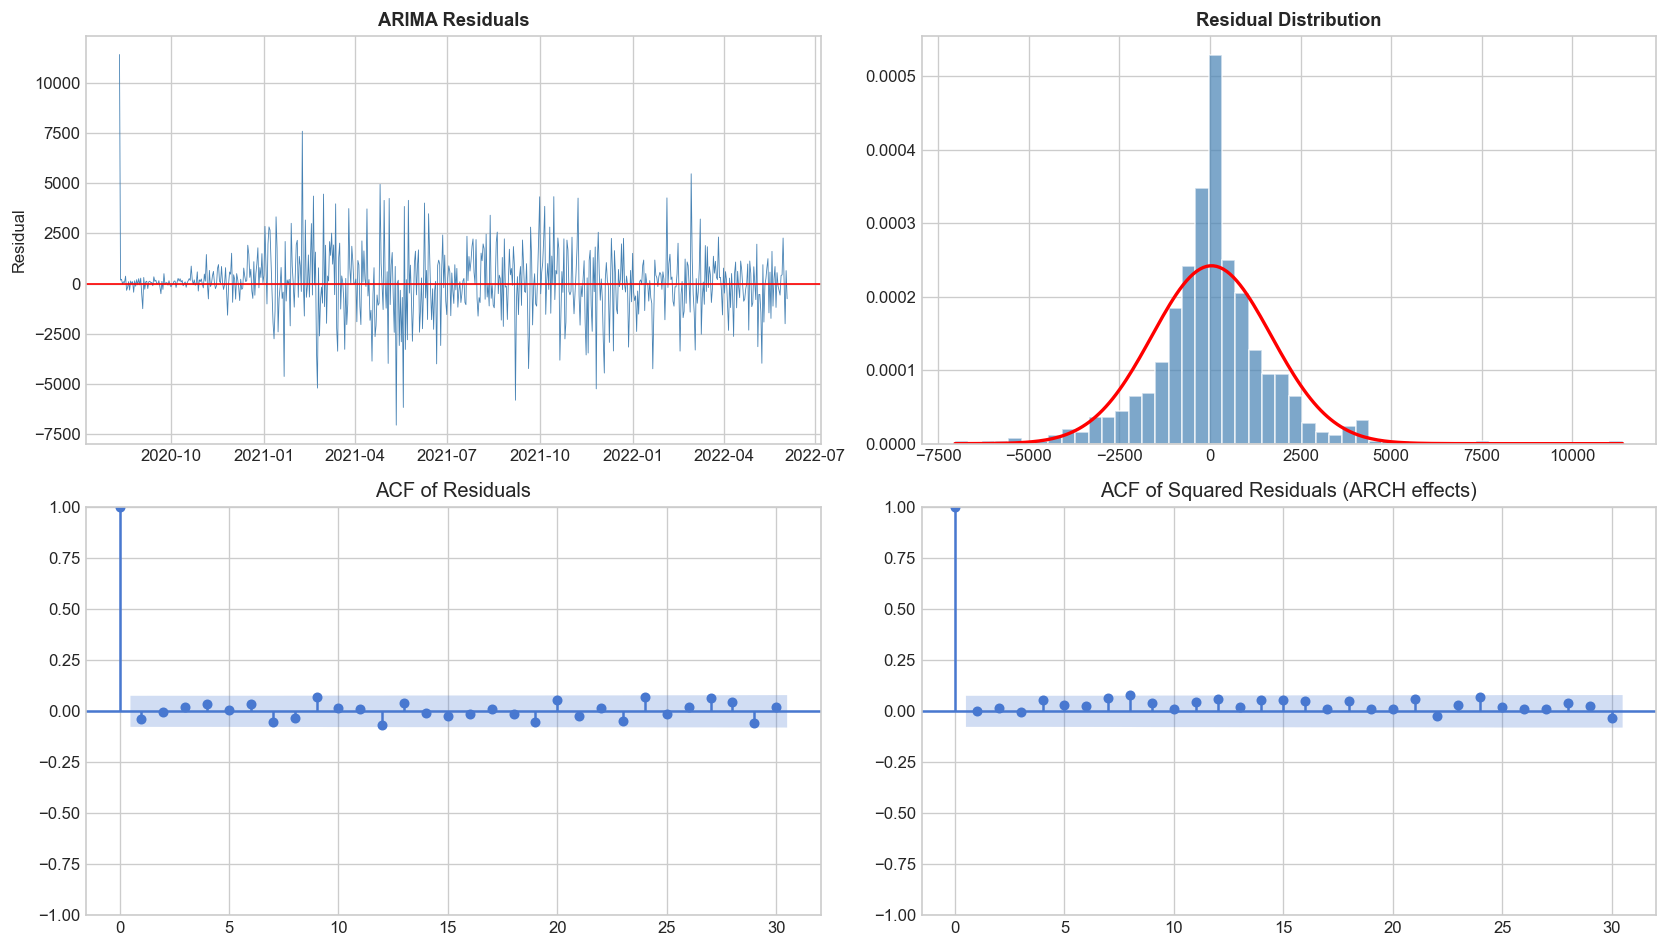

Ljung-Box Test (H₀: no autocorrelation in residuals):
      lb_stat  lb_pvalue
10   9.124857   0.520297
20  17.907507   0.593501
30  30.873518   0.421644
→ ✓ Residuals are white noise

Engle's ARCH Test (H₀: no ARCH effects / homoskedasticity):
  LM Statistic : 42.6513
  p-value      : 0.000006
→ ✗ ARCH effects detected → GARCH modeling is justified


In [13]:
# ============================================================
# 8.4 Residual Diagnostics
# ============================================================
arima_residuals = arima_fitted.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residual plot
axes[0, 0].plot(arima_residuals.index, arima_residuals.values, color='steelblue', linewidth=0.5)
axes[0, 0].axhline(y=0, color='red', linewidth=1)
axes[0, 0].set_title('ARIMA Residuals', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residual')

# Residual histogram
axes[0, 1].hist(arima_residuals, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
x_r = np.linspace(arima_residuals.min(), arima_residuals.max(), 200)
axes[0, 1].plot(x_r, norm.pdf(x_r, arima_residuals.mean(), arima_residuals.std()), 'r-', linewidth=2)
axes[0, 1].set_title('Residual Distribution', fontsize=11, fontweight='bold')

# ACF of residuals
plot_acf(arima_residuals, lags=30, ax=axes[1, 0], title='ACF of Residuals')

# ACF of squared residuals (test for ARCH effects)
plot_acf(arima_residuals**2, lags=30, ax=axes[1, 1], title='ACF of Squared Residuals (ARCH effects)')

plt.tight_layout()
plt.show()

# Ljung-Box test for remaining autocorrelation
lb_test = acorr_ljungbox(arima_residuals, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test (H₀: no autocorrelation in residuals):")
print(lb_test.to_string())
lb_conclusion = "✓ Residuals are white noise" if all(lb_test['lb_pvalue'] > 0.05) else "✗ Residuals still have autocorrelation"
print(f"→ {lb_conclusion}\n")

# ARCH effect test (Engle's test for heteroskedasticity)
arch_test = het_arch(arima_residuals.dropna(), nlags=10)
print("Engle's ARCH Test (H₀: no ARCH effects / homoskedasticity):")
print(f"  LM Statistic : {arch_test[0]:.4f}")
print(f"  p-value      : {arch_test[1]:.6f}")
arch_conclusion = "✗ ARCH effects detected → GARCH modeling is justified" if arch_test[1] < 0.05 else "✓ No ARCH effects"
print(f"→ {arch_conclusion}")

---

## 9. Deep Learning Models (LSTM, Bi-LSTM, GRU)

### Data Preparation Approach:
1. **4-Hour Frequency** — Resample raw minute data to 4H bars → **6× more training data** (~10,000 vs 1,700 samples)
2. **Fear & Greed Index** — External sentiment data fetched from API (daily, forward-filled to 4H)
3. **Enhanced Features** — Core price features + momentum/trend indicators (EMA crossover, MACD, Bollinger %B) to improve directional accuracy

### Models:
- **LSTM** — Unidirectional LSTM, captures forward temporal dependencies
- **Bi-LSTM** — Bidirectional LSTM, processes sequences in both directions for richer context
- **GRU** — Gated Recurrent Unit, fewer parameters than LSTM (no separate cell state), often faster to train with comparable accuracy

### 9.1 Data Preparation (4H Frequency + Enhanced Features)

In [14]:

# ============================================================
# 9.1 Data Preparation (4H Frequency + Enhanced Features)
# ============================================================
import requests

btc_raw = pd.read_parquet('data/BTC-USDT.parquet')
if not isinstance(btc_raw.index, pd.DatetimeIndex):
    btc_raw['open_time'] = pd.to_datetime(btc_raw['open_time'],
        unit='ms' if btc_raw['open_time'].dtype == 'int64' else None)
    btc_raw.set_index('open_time', inplace=True)
btc_raw.sort_index(inplace=True)

agg = {'open':'first','high':'max','low':'min','close':'last',
       'volume':'sum','number_of_trades':'sum','taker_buy_base_asset_volume':'sum'}
btc_4h          = btc_raw[list(agg)].resample('4h').agg(agg).dropna()
btc_daily_ohlcv = btc_raw[list(agg)].resample('D').agg(agg).dropna()
print(f"4H bars: {len(btc_4h)} | Period: {btc_4h.index[0].date()} → {btc_4h.index[-1].date()}")

# Fear & Greed Index
fng_data = None
try:
    resp = requests.get('https://api.alternative.me/fng/?limit=0&format=json', timeout=15)
    if resp.status_code == 200:
        fng_df = pd.DataFrame(resp.json()['data'])
        fng_df['timestamp'] = pd.to_datetime(fng_df['timestamp'].astype(int), unit='s')
        fng_df['fng_value']  = fng_df['value'].astype(float)
        fng_df.set_index('timestamp', inplace=True)
        fng_data = fng_df[['fng_value']].sort_index()
        print(f"Fear & Greed: {len(fng_data)} days")
except Exception as e:
    print(f"Fear & Greed unavailable: {e}")

# Technical indicators
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    return 100 - (100 / (1 + gain / (loss + 1e-10)))

close_4h  = btc_4h['close']
ema_short = close_4h.ewm(span=12*6, adjust=False).mean()
ema_long  = close_4h.ewm(span=26*6, adjust=False).mean()
macd_hist = (ema_short - ema_long) - (ema_short - ema_long).ewm(span=9*6, adjust=False).mean()
bb_mid    = close_4h.rolling(120).mean()
bb_std    = close_4h.rolling(120).std()

# === FIX: predict log_return (stationary + bounded) instead of raw close price ===
# Avoids MinMaxScaler extrapolation on unseen price levels during the test period.
# Reconstruction: pred_price[t] = actual_close[t-1] * exp(pred_log_return[t])
btc_4h['log_return']     = np.log(close_4h / close_4h.shift(1))
btc_4h['volatility_42b'] = btc_4h['log_return'].rolling(42).std()
btc_4h['rsi_84']         = compute_rsi(close_4h, 84)
btc_4h['log_volume']     = np.log1p(btc_4h['volume'])
btc_4h['ema_ratio']      = (ema_short / ema_long - 1) * 100
btc_4h['macd_hist_norm'] = macd_hist / close_4h * 100
btc_4h['bb_pctb']        = (close_4h - (bb_mid - 2*bb_std)) / (4*bb_std + 1e-10)
btc_4h['roc_30']         = close_4h.pct_change(30) * 100

if fng_data is not None:
    btc_4h = btc_4h.merge(fng_data, left_index=True, right_index=True, how='left')
    btc_4h['fng_value'] = btc_4h['fng_value'].ffill()
    has_fng = btc_4h['fng_value'].notna().any()
    if not has_fng:
        btc_4h.drop('fng_value', axis=1, inplace=True)
else:
    has_fng = False

btc_4h.dropna(inplace=True)

# All features are stationary — no raw close price (avoids scaler extrapolation)
feature_cols = ['log_return', 'volatility_42b', 'rsi_84', 'log_volume',
                'ema_ratio', 'macd_hist_norm', 'bb_pctb', 'roc_30']
if has_fng:
    feature_cols.append('fng_value')

n_features = len(feature_cols)
target_idx = feature_cols.index('log_return')

# Train/test split aligned with ARIMA
train_mask = btc_4h.index < split_date
test_end   = test_price.index[-1]
test_mask  = (btc_4h.index >= split_date) & (btc_4h.index <= test_end + pd.Timedelta(hours=23))

train_data_raw = btc_4h.loc[train_mask, feature_cols]
test_data_raw  = btc_4h.loc[test_mask,  feature_cols]

# Store raw close prices for rolling price reconstruction
last_train_close = btc_4h.loc[train_mask, 'close'].iloc[-1]
test_close_raw   = btc_4h.loc[test_mask,  'close'].values

# Daily ground-truth close prices for evaluation alignment
test_daily_close = btc_daily_ohlcv.loc[
    (btc_daily_ohlcv.index >= split_date) & (btc_daily_ohlcv.index <= test_end), 'close']

# Fit scaler on training data only
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data_raw)
scaled_train = scaler.transform(train_data_raw)
scaled_test  = scaler.transform(test_data_raw)

# Separate scaler for the target column — used for clean inverse transform of log_return
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(train_data_raw[['log_return']])

SEQ_LEN = 120  # 120 × 4H = 20 days of context

def create_sequences(data, seq_len, target_idx):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(scaled_train, SEQ_LEN, target_idx)
scaled_full_test  = np.vstack([scaled_train[-SEQ_LEN:], scaled_test])
X_test,  y_test   = create_sequences(scaled_full_test,  SEQ_LEN, target_idx)

print(f"\nFeatures ({n_features}): {feature_cols}")
print(f"Target   : log_return (stationary — fixes R² + scaler extrapolation)")
print(f"Window   : {SEQ_LEN} bars = {SEQ_LEN*4//24} days of context")
print(f"Train    : {len(train_data_raw)} 4H bars → {len(X_train)} sequences")
print(f"Test     : {len(test_data_raw)} 4H bars → {len(X_test)} sequences")
print(f"FNG      : {'✓ Included' if has_fng else '✗ Not available'}")


4H bars: 11489 | Period: 2017-08-17 → 2022-11-16
Fear & Greed: 2951 days

Features (9): ['log_return', 'volatility_42b', 'rsi_84', 'log_volume', 'ema_ratio', 'macd_hist_norm', 'bb_pctb', 'roc_30', 'fng_value']
Target   : log_return (stationary — fixes R² + scaler extrapolation)
Window   : 120 bars = 20 days of context
Train    : 9487 4H bars → 9367 sequences
Test     : 996 4H bars → 996 sequences
FNG      : ✓ Included


In [15]:

# ============================================================
# 9.2 LSTM — Build and Train (4H bars, predicts log_return)
# ============================================================
tf.random.set_seed(42); np.random.seed(42)

def build_lstm(seq_len, n_features):
    inp = Input(shape=(seq_len, n_features))
    x = LSTM(128, return_sequences=True)(inp)
    x = Dropout(0.2)(x)
    x = LSTM(64)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.1)(x)
    out = Dense(1)(x)
    return Model(inp, out, name='lstm')

lstm_model = build_lstm(SEQ_LEN, n_features)
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='huber')
lstm_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history = lstm_model.fit(X_train, y_train, epochs=100, batch_size=64,
                          validation_split=0.15, callbacks=callbacks, verbose=1)
print(f"\nStopped at epoch {len(history.history['loss'])} | Best val_loss: {min(history.history['val_loss']):.6f}")


Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 120, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,433 (478.25 KB)

 Trainable params: 122,305 (477.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - loss: 0.0780 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - loss: 0.0103 - val_loss: 7.8128e-04 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - loss: 0.0049 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 155ms/step - loss: 0.0035 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - loss: 0.0028 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - loss: 0.0025 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0023 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - loss: 0.0021 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0021
Epoch 9: Reduc

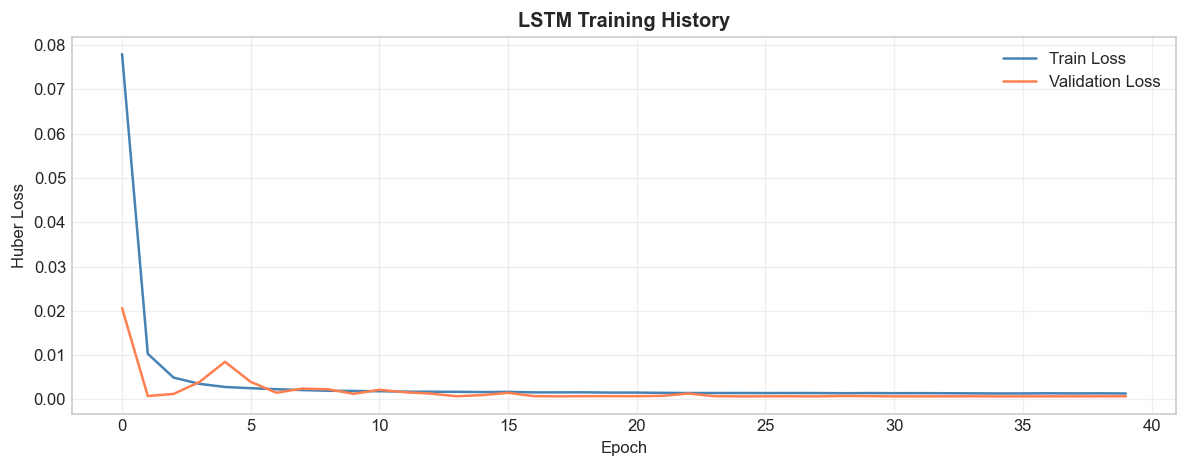

In [16]:
# ============================================================
# LSTM — Training History Visualization
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Validation Loss', color='coral')
ax.set_title('LSTM Training History', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 LSTM Forecasting and Evaluation

LSTM Results (4H → Daily, log_return reconstruction):
  MAE: $188.79  RMSE: $275.16  MAPE: 0.91%
  R²: 0.9895  Dir Acc: 78.8%  F1: 75.5%
  4H bars: 996 → 166 daily points


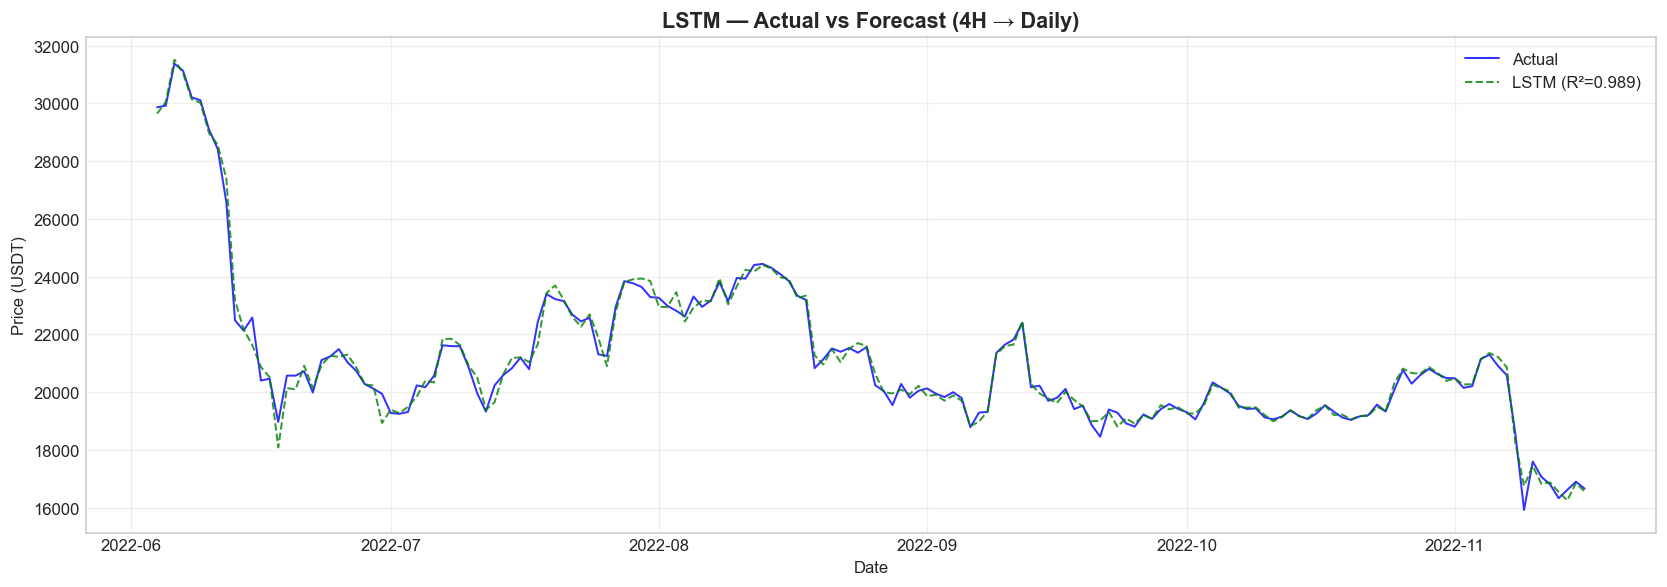

In [17]:

# ============================================================
# 9.2 LSTM — Forecasting and Evaluation (log_return → price reconstruction)
# ============================================================
# Predict scaled log_return → inverse transform → actual log_return
lstm_lr_pred = target_scaler.inverse_transform(
    lstm_model.predict(X_test, verbose=0)).flatten()

# Rolling price reconstruction: pred_price[t] = actual_close[t-1] * exp(pred_log_return[t])
# Uses the ACTUAL previous close at each step → no error accumulation
prev_close   = np.concatenate([[last_train_close], test_close_raw])[:len(lstm_lr_pred)]
lstm_pred_4h = prev_close * np.exp(lstm_lr_pred)

test_bar_dates   = test_data_raw.index[:len(lstm_pred_4h)]
pred_series_4h   = pd.Series(lstm_pred_4h,                       index=test_bar_dates)
actual_series_4h = pd.Series(test_close_raw[:len(lstm_pred_4h)], index=test_bar_dates)

# Aggregate 4H → daily (last bar per day = daily close proxy)
lstm_pred_daily   = pred_series_4h.resample('D').last().dropna()
lstm_actual_daily = actual_series_4h.resample('D').last().dropna()

common_dates = lstm_pred_daily.index.intersection(lstm_actual_daily.index)
lstm_pred    = lstm_pred_daily.loc[common_dates].values
lstm_actual  = lstm_actual_daily.loc[common_dates].values
lstm_dates   = common_dates
lstm_test_dates = lstm_dates  # alias used by downstream cells

lstm_mae  = mean_absolute_error(lstm_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_pred))
lstm_mape = np.mean(np.abs((lstm_actual - lstm_pred) / lstm_actual)) * 100
lstm_r2   = r2_score(lstm_actual, lstm_pred)

lstm_actual_dir = (np.diff(lstm_actual) > 0).astype(int)
lstm_pred_dir   = (np.diff(lstm_pred)   > 0).astype(int)
lstm_dir_acc    = accuracy_score(lstm_actual_dir, lstm_pred_dir) * 100
lstm_f1         = f1_score(lstm_actual_dir, lstm_pred_dir, zero_division=0) * 100

print(f"LSTM Results (4H → Daily, log_return reconstruction):")
print(f"  MAE: ${lstm_mae:,.2f}  RMSE: ${lstm_rmse:,.2f}  MAPE: {lstm_mape:.2f}%")
print(f"  R²: {lstm_r2:.4f}  Dir Acc: {lstm_dir_acc:.1f}%  F1: {lstm_f1:.1f}%")
print(f"  4H bars: {len(lstm_pred_4h)} → {len(lstm_pred)} daily points")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lstm_dates, lstm_actual, 'b-',  lw=1.2, label='Actual', alpha=0.8)
ax.plot(lstm_dates, lstm_pred,   'g--', lw=1.2, label=f'LSTM (R²={lstm_r2:.3f})', alpha=0.8)
ax.set_title('LSTM — Actual vs Forecast (4H → Daily)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USDT)'); ax.set_xlabel('Date')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### 9.3 Bi-LSTM — Bidirectional LSTM

The **Bi-LSTM** processes the input sequence in both **forward** and **backward** directions simultaneously. This allows the model to capture patterns from both past and future context within the sequence window, often improving forecasting performance on time series with complex temporal dependencies.

In [18]:

# ============================================================
# 9.3 Bi-LSTM — Build and Train (4H bars, predicts log_return)
# ============================================================
tf.random.set_seed(42); np.random.seed(42)

def build_bilstm(seq_len, n_features):
    inp = Input(shape=(seq_len, n_features))
    x = Bidirectional(LSTM(128, return_sequences=True))(inp)
    x = Dropout(0.2)(x)
    x = Bidirectional(LSTM(64))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.1)(x)
    out = Dense(1)(x)
    return Model(inp, out, name='bilstm')

bilstm_model = build_bilstm(SEQ_LEN, n_features)
bilstm_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='huber')
bilstm_model.summary()

bilstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]
bilstm_history = bilstm_model.fit(X_train, y_train, epochs=100, batch_size=64,
                                   validation_split=0.15, callbacks=bilstm_callbacks, verbose=1)
print(f"\nStopped at epoch {len(bilstm_history.history['loss'])} | Best val_loss: {min(bilstm_history.history['val_loss']):.6f}")


Model: "bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 120, 256)       │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,545 (1.21 MB)

 Trainable params: 316,289 (1.21 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 202ms/step - loss: 0.0720 - val_loss: 0.0718 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 186ms/step - loss: 0.0133 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - loss: 0.0073 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 204ms/step - loss: 0.0049 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 206ms/step - loss: 0.0036 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 203ms/step - loss: 0.0030 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 222ms/step - loss: 0.0026 - val_loss: 7.4031e-04 - learning_rate: 0.0010
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 252ms/step - loss: 0.0024 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 262ms/step - loss: 0.0022 - val_loss: 8

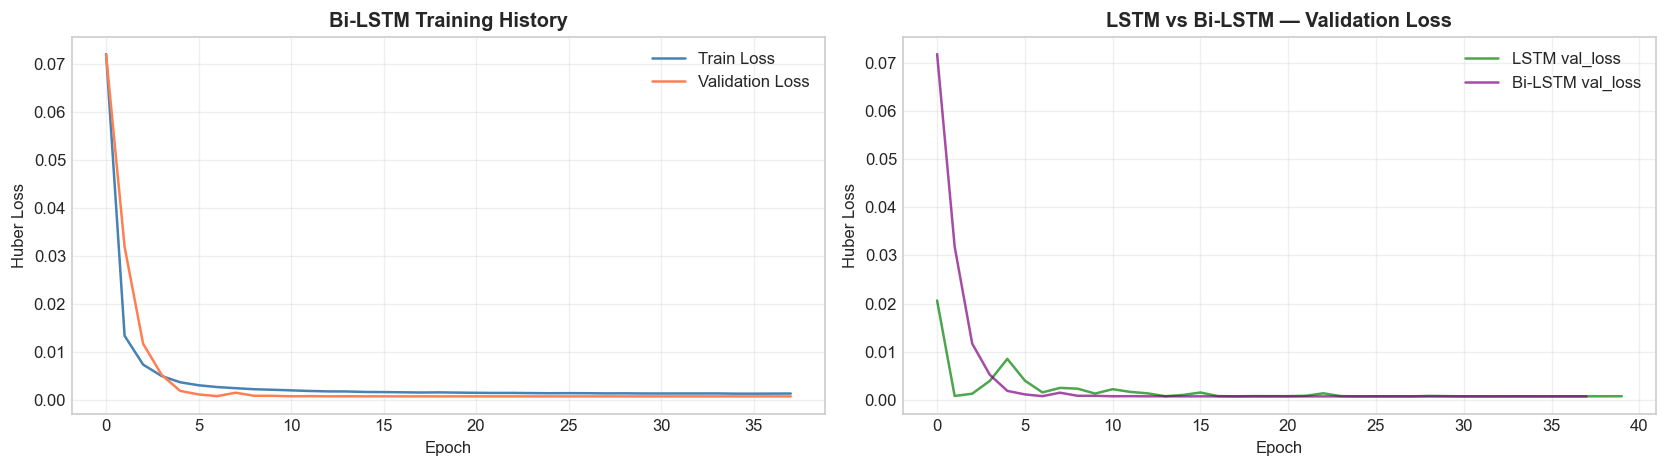

In [19]:
# ============================================================
# Bi-LSTM — Training History Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bi-LSTM training curve
axes[0].plot(bilstm_history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(bilstm_history.history['val_loss'], label='Validation Loss', color='coral')
axes[0].set_title('Bi-LSTM Training History', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM vs Bi-LSTM comparison
axes[1].plot(history.history['val_loss'], label='LSTM val_loss', color='green', alpha=0.7)
axes[1].plot(bilstm_history.history['val_loss'], label='Bi-LSTM val_loss', color='purple', alpha=0.7)
axes[1].set_title('LSTM vs Bi-LSTM — Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Huber Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Bi-LSTM Results (4H → Daily, log_return reconstruction):
  MAE: $187.60  RMSE: $277.67  MAPE: 0.90%
  R²: 0.9893  Dir Acc: 78.8%  F1: 75.5%

LSTM vs Bi-LSTM — R²: 0.9895 vs 0.9893 | Dir Acc: 78.8% vs 78.8%


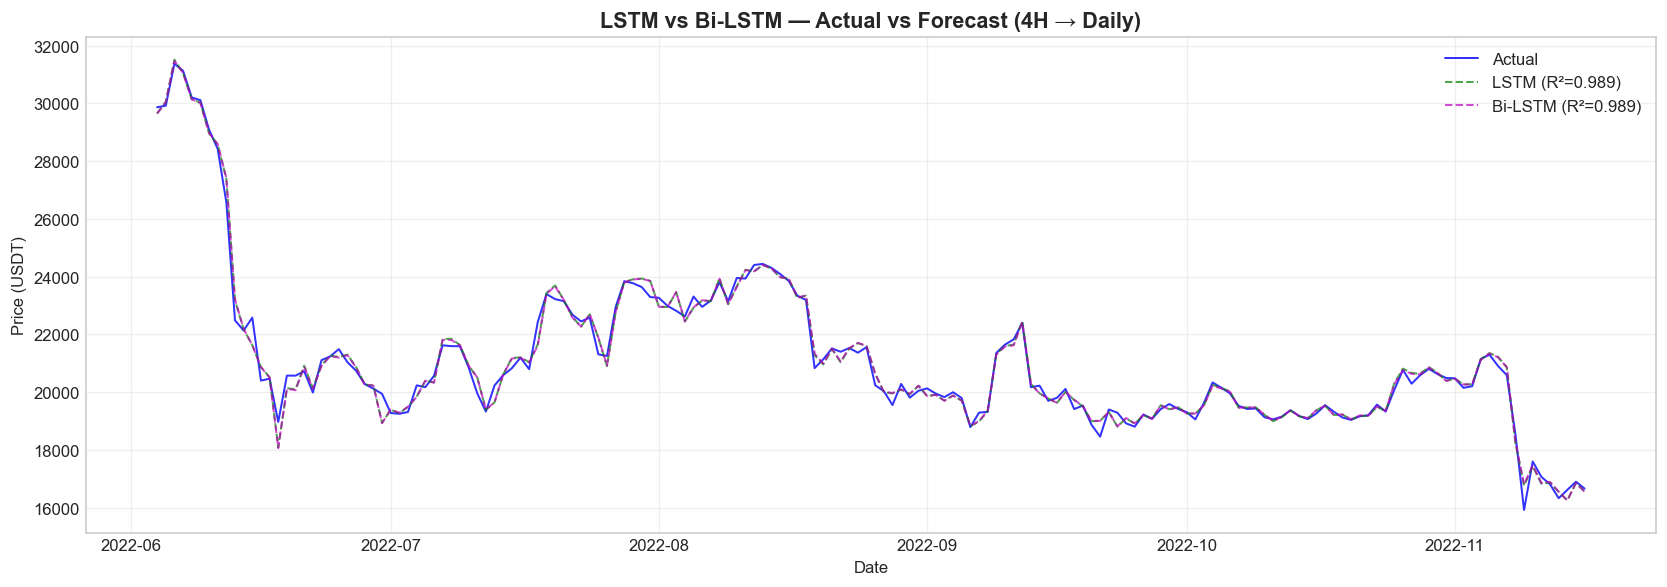

In [20]:

# ============================================================
# 9.3 Bi-LSTM — Forecasting and Evaluation (log_return → price reconstruction)
# ============================================================
bilstm_lr_pred = target_scaler.inverse_transform(
    bilstm_model.predict(X_test, verbose=0)).flatten()

prev_close      = np.concatenate([[last_train_close], test_close_raw])[:len(bilstm_lr_pred)]
bilstm_pred_4h  = prev_close * np.exp(bilstm_lr_pred)

bilstm_pred_series_4h = pd.Series(bilstm_pred_4h, index=test_data_raw.index[:len(bilstm_pred_4h)])
bilstm_pred_daily     = bilstm_pred_series_4h.resample('D').last().dropna()

common_dates  = bilstm_pred_daily.index.intersection(lstm_actual_daily.index)
bilstm_pred   = bilstm_pred_daily.loc[common_dates].values
bilstm_actual = lstm_actual_daily.loc[common_dates].values
bilstm_dates  = common_dates

bilstm_mae  = mean_absolute_error(bilstm_actual, bilstm_pred)
bilstm_rmse = np.sqrt(mean_squared_error(bilstm_actual, bilstm_pred))
bilstm_mape = np.mean(np.abs((bilstm_actual - bilstm_pred) / bilstm_actual)) * 100
bilstm_r2   = r2_score(bilstm_actual, bilstm_pred)

bilstm_actual_dir = (np.diff(bilstm_actual) > 0).astype(int)
bilstm_pred_dir   = (np.diff(bilstm_pred)   > 0).astype(int)
bilstm_dir_acc    = accuracy_score(bilstm_actual_dir, bilstm_pred_dir) * 100
bilstm_f1         = f1_score(bilstm_actual_dir, bilstm_pred_dir, zero_division=0) * 100

print(f"Bi-LSTM Results (4H → Daily, log_return reconstruction):")
print(f"  MAE: ${bilstm_mae:,.2f}  RMSE: ${bilstm_rmse:,.2f}  MAPE: {bilstm_mape:.2f}%")
print(f"  R²: {bilstm_r2:.4f}  Dir Acc: {bilstm_dir_acc:.1f}%  F1: {bilstm_f1:.1f}%")
print(f"\nLSTM vs Bi-LSTM — R²: {lstm_r2:.4f} vs {bilstm_r2:.4f} | Dir Acc: {lstm_dir_acc:.1f}% vs {bilstm_dir_acc:.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bilstm_dates,   bilstm_actual, 'b-',  lw=1.2, label='Actual', alpha=0.8)
ax.plot(lstm_test_dates, lstm_pred,    'g--', lw=1.2, label=f'LSTM (R²={lstm_r2:.3f})', alpha=0.7)
ax.plot(bilstm_dates,   bilstm_pred,   'm--', lw=1.2, label=f'Bi-LSTM (R²={bilstm_r2:.3f})', alpha=0.7)
ax.set_title('LSTM vs Bi-LSTM — Actual vs Forecast (4H → Daily)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USDT)'); ax.set_xlabel('Date')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### 9.4 GRU — Gated Recurrent Unit

The **GRU** combines the forget and input gates of LSTM into a single **update gate**, and merges the cell state and hidden state. This results in **fewer parameters** than LSTM while maintaining comparable performance. GRU is often faster to train and can generalize better on smaller datasets.

In [21]:

# ============================================================
# 9.4 GRU — Build and Train (4H bars, predicts log_return)
# ============================================================
tf.random.set_seed(42); np.random.seed(42)

def build_gru(seq_len, n_features):
    inp = Input(shape=(seq_len, n_features))
    x = GRU(128, return_sequences=True)(inp)
    x = Dropout(0.2)(x)
    x = GRU(64)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.1)(x)
    out = Dense(1)(x)
    return Model(inp, out, name='gru')

gru_model = build_gru(SEQ_LEN, n_features)
gru_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='huber')
gru_model.summary()

gru_callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]
gru_history = gru_model.fit(X_train, y_train, epochs=100, batch_size=64,
                              validation_split=0.15, callbacks=gru_callbacks, verbose=1)
print(f"\nStopped at epoch {len(gru_history.history['loss'])} | Best val_loss: {min(gru_history.history['val_loss']):.6f}")
print(f"GRU has ~25% fewer parameters than LSTM (no separate cell state gate)")


Model: "gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 120, 128)       │        53,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,993 (363.25 KB)

 Trainable params: 92,865 (362.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - loss: 0.1075 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - loss: 0.0249 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - loss: 0.0123 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - loss: 0.0073 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - loss: 0.0052 - val_loss: 9.1946e-04 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - loss: 0.0039 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - loss: 0.0033 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - loss: 0.0029 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - loss: 0.0026 - val_loss: 0

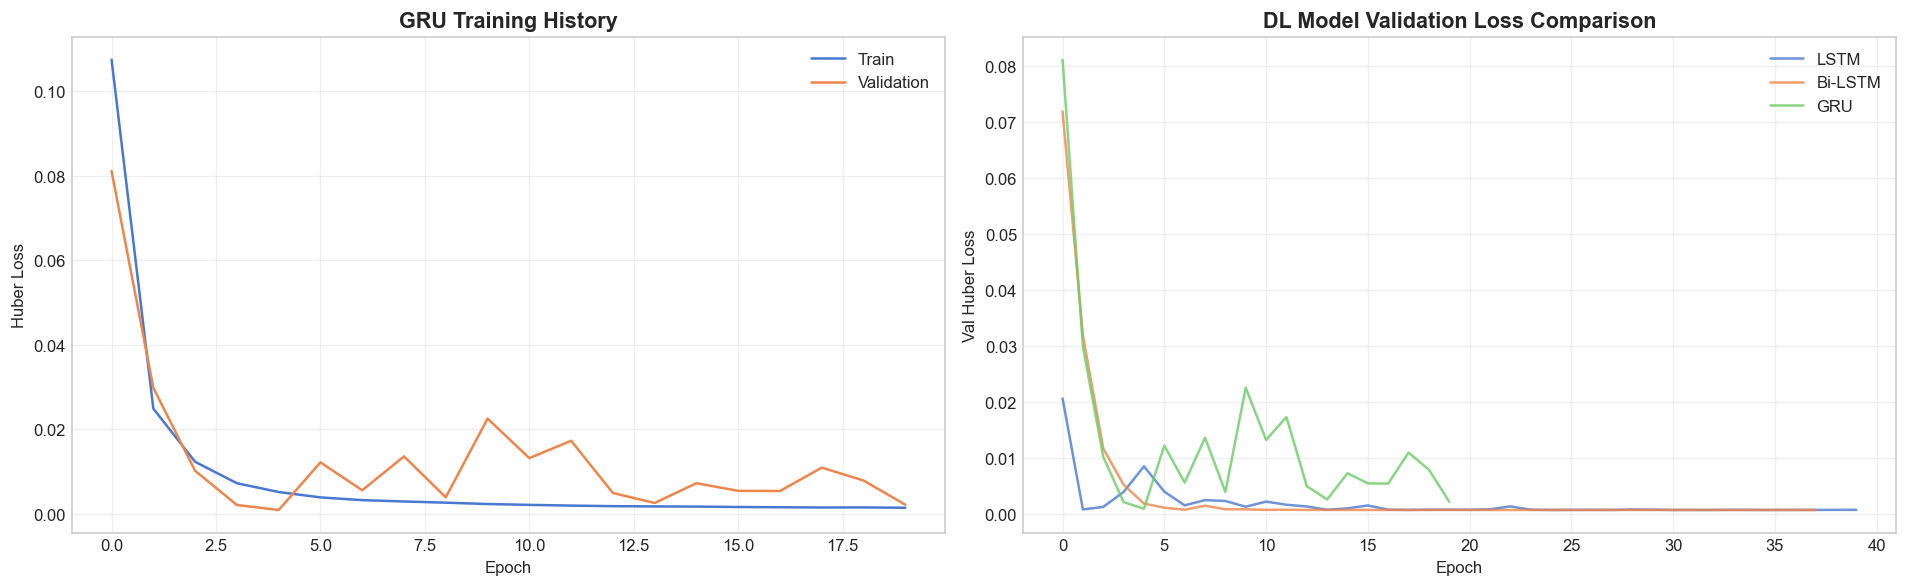

GRU training curves and DL model comparison saved.


In [22]:
# ============================================================
# 9.4 GRU Training History & Comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---------- GRU curves ----------
axes[0].plot(gru_history.history['loss'], label='Train', linewidth=1.5)
axes[0].plot(gru_history.history['val_loss'], label='Validation', linewidth=1.5)
axes[0].set_title('GRU Training History', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ---------- All DL models val_loss comparison ----------
axes[1].plot(history.history['val_loss'], label='LSTM', linewidth=1.5, alpha=0.8)
axes[1].plot(bilstm_history.history['val_loss'], label='Bi-LSTM', linewidth=1.5, alpha=0.8)
axes[1].plot(gru_history.history['val_loss'], label='GRU', linewidth=1.5, alpha=0.8)
axes[1].set_title('DL Model Validation Loss Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Huber Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gru_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("GRU training curves and DL model comparison saved.")

GRU Results (4H → Daily, log_return reconstruction):
  MAE: $247.71  RMSE: $352.00  MAPE: 1.20%
  R²: 0.9828  Dir Acc: 78.8%  F1: 75.9%

Model           MAE ($)     RMSE ($)       R²   Dir Acc       F1
  ----------------------------------------------------------
  LSTM             188.79       275.16   0.9895      78.8%    75.5%
  Bi-LSTM          187.60       277.67   0.9893      78.8%    75.5%
  GRU              247.71       352.00   0.9828      78.8%    75.9%


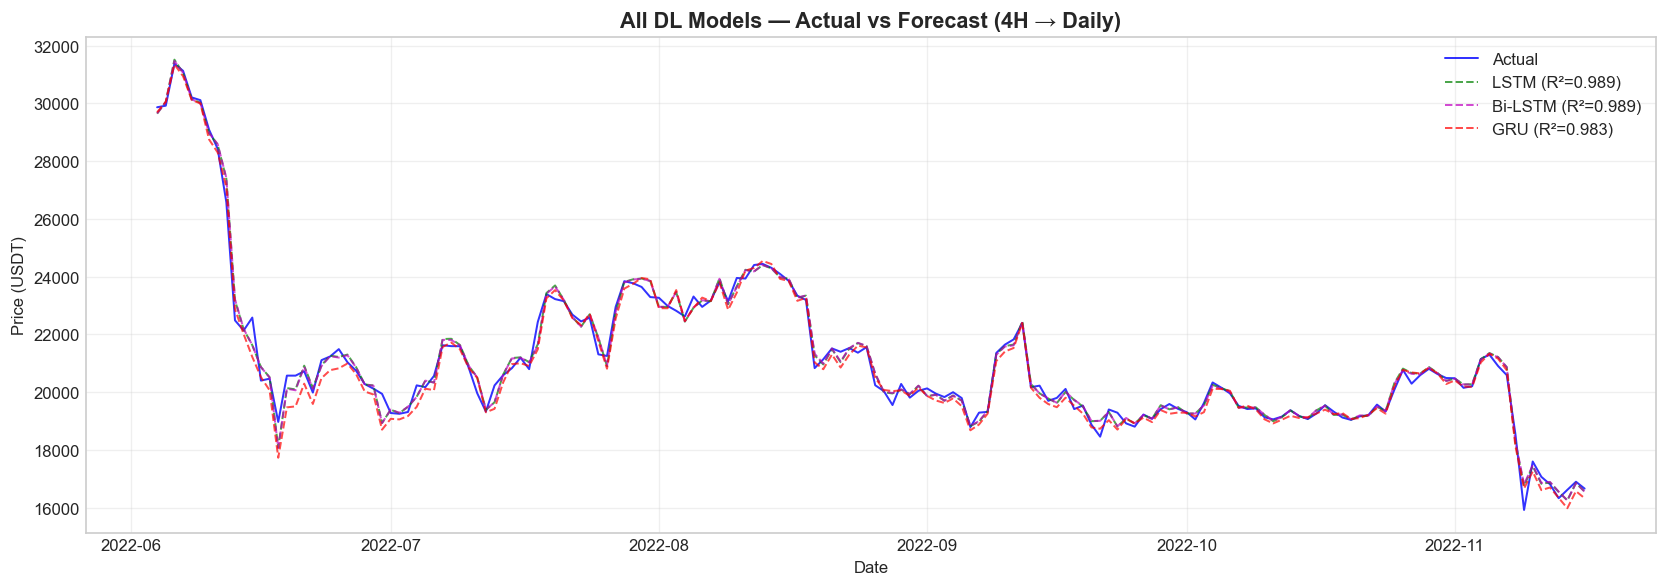

In [23]:

# ============================================================
# 9.4 GRU — Forecasting and Evaluation (log_return → price reconstruction)
# ============================================================
gru_lr_pred = target_scaler.inverse_transform(
    gru_model.predict(X_test, verbose=0)).flatten()

prev_close   = np.concatenate([[last_train_close], test_close_raw])[:len(gru_lr_pred)]
gru_pred_4h  = prev_close * np.exp(gru_lr_pred)

gru_pred_series_4h = pd.Series(gru_pred_4h, index=test_data_raw.index[:len(gru_pred_4h)])
gru_pred_daily     = gru_pred_series_4h.resample('D').last().dropna()

common_dates = gru_pred_daily.index.intersection(lstm_actual_daily.index)
gru_pred     = gru_pred_daily.loc[common_dates].values
gru_actual   = lstm_actual_daily.loc[common_dates].values
gru_dates    = common_dates

gru_mae  = mean_absolute_error(gru_actual, gru_pred)
gru_rmse = np.sqrt(mean_squared_error(gru_actual, gru_pred))
gru_mape = np.mean(np.abs((gru_actual - gru_pred) / gru_actual)) * 100
gru_r2   = r2_score(gru_actual, gru_pred)

gru_actual_dir = (np.diff(gru_actual) > 0).astype(int)
gru_pred_dir   = (np.diff(gru_pred)   > 0).astype(int)
gru_dir_acc    = accuracy_score(gru_actual_dir, gru_pred_dir) * 100
gru_f1         = f1_score(gru_actual_dir, gru_pred_dir, zero_division=0) * 100

print(f"GRU Results (4H → Daily, log_return reconstruction):")
print(f"  MAE: ${gru_mae:,.2f}  RMSE: ${gru_rmse:,.2f}  MAPE: {gru_mape:.2f}%")
print(f"  R²: {gru_r2:.4f}  Dir Acc: {gru_dir_acc:.1f}%  F1: {gru_f1:.1f}%")

print(f"\n{'='*65}")
print(f"{'Model':<10} {'MAE ($)':>12} {'RMSE ($)':>12} {'R²':>8} {'Dir Acc':>9} {'F1':>8}")
print(f"  {'-'*58}")
for name, mae, rmse, r2, da, f1 in [
    ('LSTM',    lstm_mae,   lstm_rmse,   lstm_r2,   lstm_dir_acc,   lstm_f1),
    ('Bi-LSTM', bilstm_mae, bilstm_rmse, bilstm_r2, bilstm_dir_acc, bilstm_f1),
    ('GRU',     gru_mae,    gru_rmse,    gru_r2,    gru_dir_acc,    gru_f1),
]:
    print(f"  {name:<10} {mae:>12,.2f} {rmse:>12,.2f} {r2:>8.4f} {da:>9.1f}% {f1:>7.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gru_dates,    gru_actual,  'b-',  lw=1.2, label='Actual', alpha=0.8)
ax.plot(lstm_dates,   lstm_pred,   'g--', lw=1.2, label=f'LSTM (R²={lstm_r2:.3f})',    alpha=0.7)
ax.plot(bilstm_dates, bilstm_pred, 'm--', lw=1.2, label=f'Bi-LSTM (R²={bilstm_r2:.3f})', alpha=0.7)
ax.plot(gru_dates,    gru_pred,    'r--', lw=1.2, label=f'GRU (R²={gru_r2:.3f})',     alpha=0.7)
ax.set_title('All DL Models — Actual vs Forecast (4H → Daily)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USDT)'); ax.set_xlabel('Date')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


ADF Tests on Daily Returns (all assets):
ADF Test — ADA_USDT
  Test Statistic : -8.3310
  p-value        : 0.000000
  Lags Used      : 8
  Observations   : 818
  Critical Values: 1%=-3.4384, 5%=-2.8651, 10%=-2.5687
  Result         : ✓ STATIONARY

ADF Test — BNB_USDT
  Test Statistic : -6.6317
  p-value        : 0.000000
  Lags Used      : 9
  Observations   : 817
  Critical Values: 1%=-3.4384, 5%=-2.8651, 10%=-2.5687
  Result         : ✓ STATIONARY

ADF Test — BTC_USDT
  Test Statistic : -29.7003
  p-value        : 0.000000
  Lags Used      : 0
  Observations   : 826
  Critical Values: 1%=-3.4383, 5%=-2.8650, 10%=-2.5686
  Result         : ✓ STATIONARY

ADF Test — ETH_USDT
  Test Statistic : -8.3453
  p-value        : 0.000000
  Lags Used      : 9
  Observations   : 817
  Critical Values: 1%=-3.4384, 5%=-2.8651, 10%=-2.5687
  Result         : ✓ STATIONARY

ADF Test — SOL_USDT
  Test Statistic : -30.7095
  p-value        : 0.000000
  Lags Used      : 0
  Observations   : 826
  Critical

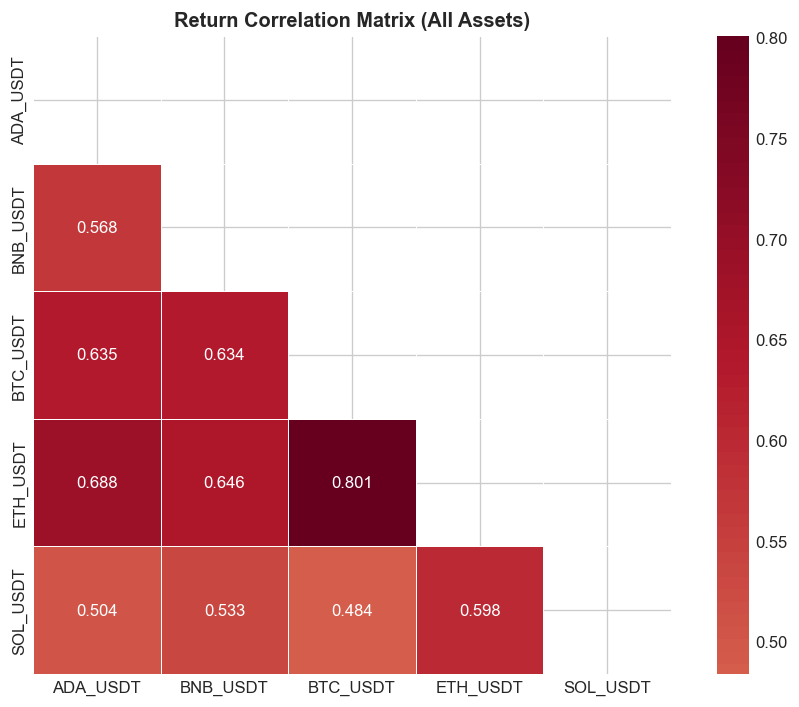

In [24]:
# ============================================================
# 10.1 VAR Data Preparation — Verify stationarity of all assets
# ============================================================
print("ADF Tests on Daily Returns (all assets):")
print("=" * 60)
for col in df_returns.columns:
    adf_test(df_returns[col], col)

# Correlation heatmap of returns
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, mask=mask,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Return Correlation Matrix (All Assets)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Model Selection — Optimal Lag Order

In [25]:
# ============================================================
# 10.2 VAR Model Selection — Lag Order via AIC/BIC
# ============================================================
var_model = VAR(train_returns)
lag_selection = var_model.select_order(maxlags=15)
print("VAR Lag Order Selection:")
print(lag_selection.summary())

optimal_lag = lag_selection.aic
print(f"\n→ Optimal lag (AIC): {optimal_lag}")

VAR Lag Order Selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        15.03      15.07*   3.384e+06      15.05*
1        15.01       15.22   3.314e+06       15.09
2       14.98*       15.36  3.213e+06*       15.13
3        15.00       15.55   3.275e+06       15.22
4        15.02       15.75   3.352e+06       15.31
5        15.01       15.91   3.299e+06       15.36
6        15.02       16.09   3.332e+06       15.43
7        15.04       16.29   3.411e+06       15.52
8        15.07       16.48   3.495e+06       15.62
9        15.03       16.62   3.358e+06       15.64
10       15.01       16.77   3.293e+06       15.69
11       15.03       16.96   3.362e+06       15.78
12       15.03       17.14   3.380e+06       15.85
13       15.04       17.32   3.417e+06       15.93
14       15.08       17.54   3.569e+06       16.04
15       15.07       17.70   3.538e+06       16.09
------

### 10.3 Model Fitting and Forecasting

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 05, Mar, 2026
Time:                     21:06:12
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    15.3028
Nobs:                     660.000    HQIC:                   15.0736
Log likelihood:          -9553.89    FPE:                3.04337e+06
AIC:                      14.9285    Det(Omega_mle):     2.80196e+06
--------------------------------------------------------------------
Results for equation ADA_USDT
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.381722         0.251753            1.516           0.129
L1.ADA_USDT        -0.005884         0.055997           -0.105           0.916
L1.BNB_USDT         0.134683         0.053613            2.512   

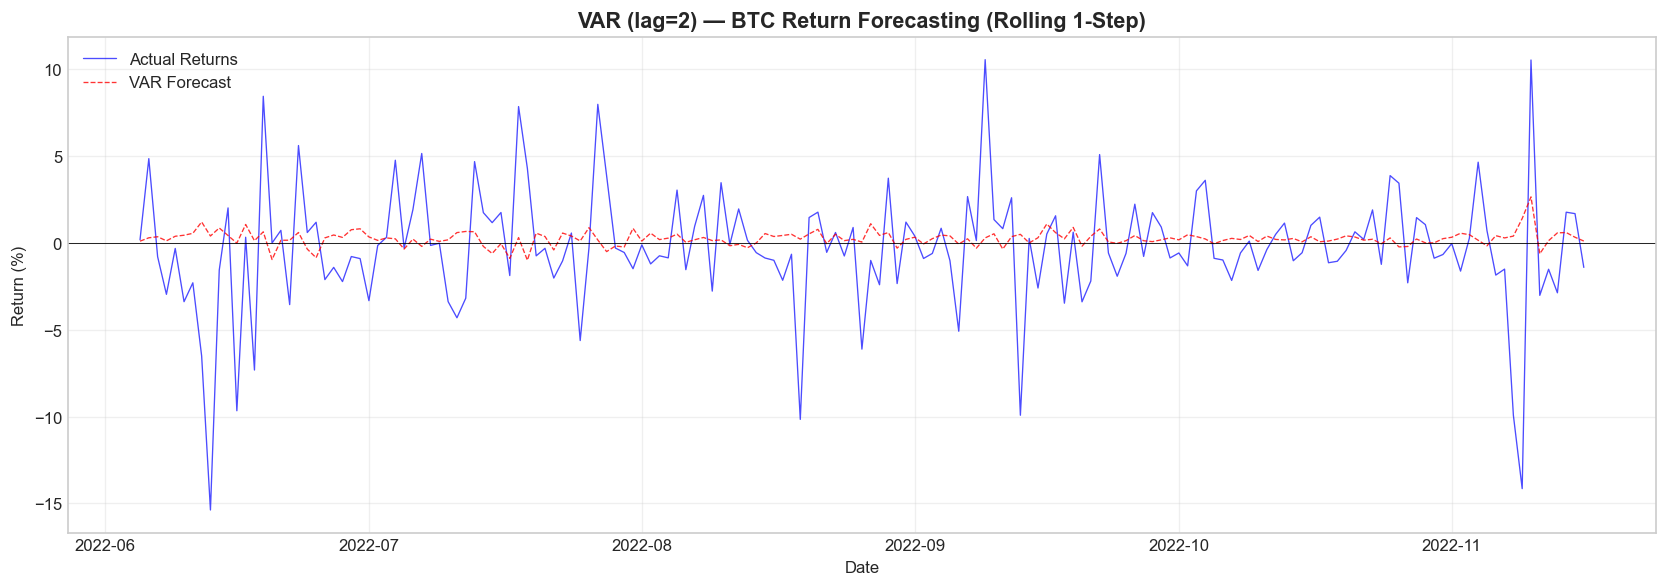

In [26]:
# ============================================================
# 10.3 VAR Model Fitting and Forecasting (Rolling One-Step-Ahead)
# ============================================================
var_fitted = var_model.fit(optimal_lag)
print(var_fitted.summary())

# Rolling one-step-ahead forecast (using actual observed values)
print(f"\nRunning rolling one-step-ahead VAR(lag={optimal_lag}) forecast...")
all_returns = df_returns.values  # full return series
var_forecast_vals = []
for t in range(len(train_returns), len(df_returns)):
    # Use last 'optimal_lag' actual observations as input
    lag_data = all_returns[t - optimal_lag:t]
    fc = var_fitted.forecast(lag_data, steps=1)
    var_forecast_vals.append(fc[0])

var_forecast_df = pd.DataFrame(var_forecast_vals, index=test_returns.index, columns=df_returns.columns)

# BTC return metrics
var_mae = mean_absolute_error(test_returns[btc_col], var_forecast_df[btc_col])
var_rmse = np.sqrt(mean_squared_error(test_returns[btc_col], var_forecast_df[btc_col]))
var_mape = np.mean(np.abs((test_returns[btc_col].values - var_forecast_df[btc_col].values) /
                           (test_returns[btc_col].values + 1e-10))) * 100
var_r2 = r2_score(test_returns[btc_col], var_forecast_df[btc_col])

# Directional accuracy (return > 0 = up, return < 0 = down)
var_actual_dir = (test_returns[btc_col] > 0).astype(int).values
var_pred_dir = (var_forecast_df[btc_col] > 0).astype(int).values
var_dir_acc = accuracy_score(var_actual_dir, var_pred_dir) * 100
var_f1 = f1_score(var_actual_dir, var_pred_dir, zero_division=0) * 100

print(f"\nVAR (lag={optimal_lag}) — BTC Return Forecast Results:")
print(f"  MAE  : {var_mae:.4f}%")
print(f"  RMSE : {var_rmse:.4f}%")
print(f"  R²   : {var_r2:.4f}")
print(f"  Directional Accuracy: {var_dir_acc:.1f}%")
print(f"  F1 Score: {var_f1:.1f}%")

# Plot VAR forecast vs actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_returns.index, test_returns[btc_col].values, 'b-', linewidth=0.8, alpha=0.7, label='Actual Returns')
ax.plot(var_forecast_df.index, var_forecast_df[btc_col].values, 'r--', linewidth=0.8, alpha=0.8, label='VAR Forecast')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title(f'VAR (lag={optimal_lag}) — BTC Return Forecasting (Rolling 1-Step)', fontsize=13, fontweight='bold')
ax.set_ylabel('Return (%)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10.4 Granger Causality Analysis

Test whether other cryptocurrencies **Granger-cause** (i.e., help predict) BTC returns.

In [27]:
# ============================================================
# 10.4 Granger Causality Analysis
# ============================================================
print("Granger Causality Tests (other assets → BTC returns):")
print("=" * 60)
gc_results = []

for col in df_returns.columns:
    if col != btc_col:
        try:
            gc = grangercausalitytests(df_returns[[btc_col, col]].dropna(), maxlag=5, verbose=False)
            min_p = min([gc[lag][0]['ssr_ftest'][1] for lag in range(1, 6)])
            best_lag = min(range(1, 6), key=lambda lag: gc[lag][0]['ssr_ftest'][1])
            status = "✓ Significant" if min_p < 0.05 else "✗ Not significant"
            gc_results.append({'Asset': col, 'Min p-value': min_p, 'Best Lag': best_lag, 'Status': status})
            print(f"  {status} | {col} → {btc_col}: p={min_p:.6f} (lag={best_lag})")
        except Exception as e:
            print(f"  ? {col}: Error — {e}")

gc_df = pd.DataFrame(gc_results)
print(f"\n→ {sum(1 for r in gc_results if 'Significant' in r['Status'])} out of {len(gc_results)} assets Granger-cause BTC returns at 5% significance")

Granger Causality Tests (other assets → BTC returns):
  ✓ Significant | ADA_USDT → BTC_USDT: p=0.003809 (lag=5)
  ✓ Significant | BNB_USDT → BTC_USDT: p=0.001872 (lag=2)
  ✓ Significant | ETH_USDT → BTC_USDT: p=0.016243 (lag=1)
  ✓ Significant | SOL_USDT → BTC_USDT: p=0.002053 (lag=3)

→ 4 out of 4 assets Granger-cause BTC returns at 5% significance


### 10.5 VAR Residual Diagnostics

Check VAR residuals for serial correlation (**Durbin-Watson test**) and normality (**Jarque-Bera test**).

Durbin-Watson Test (ideal ≈ 2.0, no autocorrelation):
  ✓ ADA_USDT: DW = 1.9978
  ✓ BNB_USDT: DW = 1.9921
  ✓ BTC_USDT: DW = 2.0034
  ✓ ETH_USDT: DW = 1.9915
  ✓ SOL_USDT: DW = 2.0093

Jarque-Bera Test for Residual Normality:
  ✗ Non-normal | ADA_USDT: JB=156.90, p=8.5186e-35
  ✗ Non-normal | BNB_USDT: JB=12994.59, p=0.0000e+00
  ✗ Non-normal | BTC_USDT: JB=101.18, p=1.0706e-22
  ✗ Non-normal | ETH_USDT: JB=255.85, p=2.7696e-56
  ✗ Non-normal | SOL_USDT: JB=251.55, p=2.3835e-55


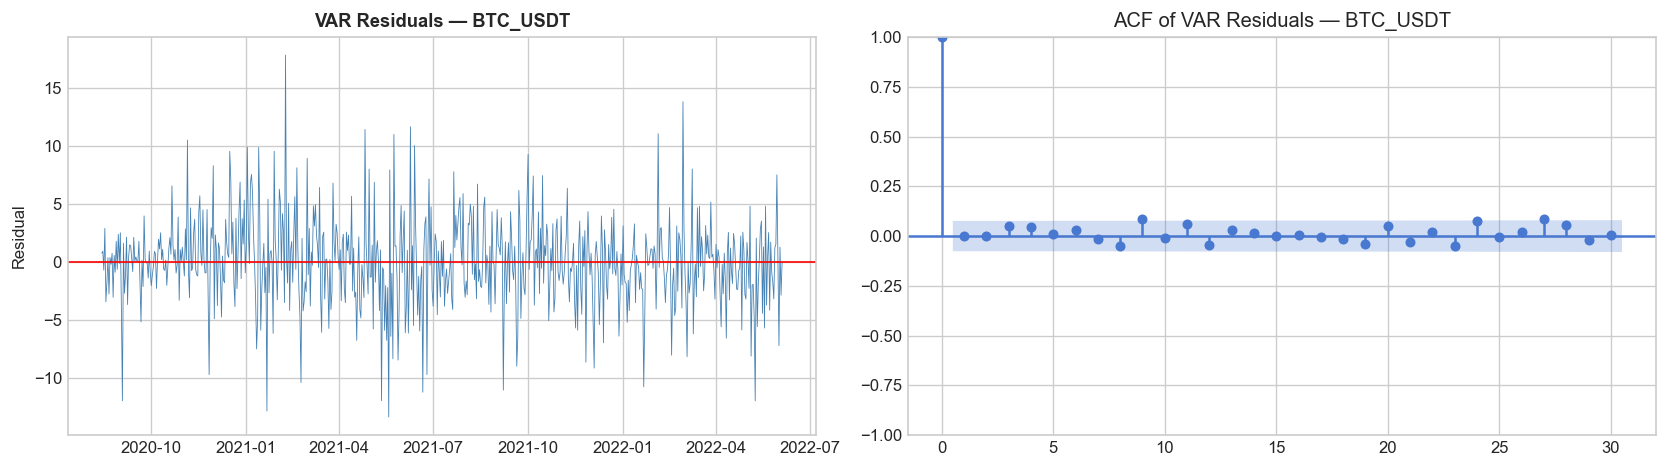

In [28]:
# ============================================================
# 10.5 VAR Residual Diagnostics
# ============================================================
var_resid = var_fitted.resid

print("Durbin-Watson Test (ideal ≈ 2.0, no autocorrelation):")
print("=" * 50)
dw_values = durbin_watson(var_resid)
for i, col in enumerate(var_resid.columns):
    status = "✓" if 1.5 < dw_values[i] < 2.5 else "✗"
    print(f"  {status} {col}: DW = {dw_values[i]:.4f}")

print("\nJarque-Bera Test for Residual Normality:")
print("=" * 50)
for col in var_resid.columns:
    jb_s, jb_p = jarque_bera(var_resid[col].dropna())
    status = "✓ Normal" if jb_p > 0.05 else "✗ Non-normal"
    print(f"  {status} | {col}: JB={jb_s:.2f}, p={jb_p:.4e}")

# Plot VAR residuals for BTC
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(var_resid[btc_col].index, var_resid[btc_col].values, color='steelblue', linewidth=0.5)
axes[0].axhline(y=0, color='red', linewidth=1)
axes[0].set_title(f'VAR Residuals — {btc_col}', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Residual')

plot_acf(var_resid[btc_col].dropna(), lags=30, ax=axes[1], title=f'ACF of VAR Residuals — {btc_col}')

plt.tight_layout()
plt.show()

---

## 11. GARCH Model (Volatility Modeling)

GARCH models the **conditional variance** (volatility) of returns. Daily returns (not raw prices) are used as input because GARCH requires a stationary series. This is particularly useful for BTC which exhibits **volatility clustering** — periods of high volatility followed by more high volatility.

### 11.1 GARCH Variants

- **GARCH(p,q):** Standard — models symmetric volatility dynamics
- **EGARCH:** Exponential — models variance in log-space (no positivity constraint), captures asymmetric effects
- **GJR-GARCH:** Threshold — uses indicator function to model the **leverage effect**

In [29]:
# ============================================================
# 11.1 Compare GARCH Variants (GARCH, EGARCH, GJR-GARCH)
# ============================================================
btc_ret_garch = df_returns[btc_col].dropna()
train_ret_garch = btc_ret_garch[:train_size]
test_ret_garch = btc_ret_garch[train_size:]

# Define variants to compare
garch_variants = [
    ('GARCH(1,1)',       {'vol': 'Garch',  'p': 1, 'q': 1}),
    ('GARCH(1,2)',       {'vol': 'Garch',  'p': 1, 'q': 2}),
    ('GARCH(2,1)',       {'vol': 'Garch',  'p': 2, 'q': 1}),
    ('EGARCH(1,1)',      {'vol': 'EGARCH', 'p': 1, 'q': 1}),
    ('EGARCH(1,2)',      {'vol': 'EGARCH', 'p': 1, 'q': 2}),
    ('GJR-GARCH(1,1,1)', {'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1}),
    ('GJR-GARCH(1,1,2)', {'vol': 'Garch',  'p': 1, 'o': 1, 'q': 2}),
]

garch_results = []
for name, config in garch_variants:
    try:
        m = arch_model(train_ret_garch, mean='constant', rescale=False, **config)
        fit = m.fit(disp='off')
        garch_results.append({
            'Model': name, 'AIC': fit.aic, 'BIC': fit.bic,
            'Log-Lik': fit.loglikelihood, 'fit': fit, 'config': config
        })
    except Exception as e:
        print(f"  {name}: Failed — {e}")

# Display comparison table (without fit objects)
garch_compare_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('fit', 'config')}
                                  for r in garch_results]).sort_values('BIC')
print("GARCH Variant Comparison (sorted by BIC):")
print(garch_compare_df.to_string(index=False))

best_garch = min(garch_results, key=lambda x: x['BIC'])
best_garch_fit = best_garch['fit']
best_garch_config = best_garch['config']
print(f"\n→ Best model: {best_garch['Model']} (BIC: {best_garch['BIC']:.2f})")

GARCH Variant Comparison (sorted by BIC):
           Model         AIC         BIC      Log-Lik
     EGARCH(1,1) 3632.778974 3650.760036 -1812.389487
      GARCH(1,1) 3635.032315 3653.013378 -1813.516158
     EGARCH(1,2) 3634.778974 3657.255302 -1812.389487
      GARCH(2,1) 3636.363460 3658.839788 -1813.181730
GJR-GARCH(1,1,1) 3636.994769 3659.471097 -1813.497385
      GARCH(1,2) 3637.032315 3659.508643 -1813.516158
GJR-GARCH(1,1,2) 3638.994769 3665.966363 -1813.497385

→ Best model: EGARCH(1,1) (BIC: 3650.76)


### 11.2 Model Selection — Best GARCH Model Summary

In [30]:
# ============================================================
# 11.2 Best GARCH Model Summary
# ============================================================
print(f"Best Model: {best_garch['Model']}")
print(best_garch_fit.summary())

Best Model: EGARCH(1,1)
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:               BTC_USDT   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -1812.39
Distribution:                  Normal   AIC:                           3632.78
Method:            Maximum Likelihood   BIC:                           3650.76
                                        No. Observations:                  662
Date:                Thu, Mar 05 2026   Df Residuals:                      661
Time:                        21:06:13   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.2451      0.137     

Running rolling GARCH(1,1) volatility forecast (expanding window)...
  Note: Using GARCH(1,1) for rolling stability (best static model: EGARCH(1,1))
  All 165 forecasts computed successfully (0 NaN)

GARCH(1,1) Rolling Forecast — Volatility Metrics:
  Volatility Directional Accuracy: 32.3%
  F1 Score: 5.1%


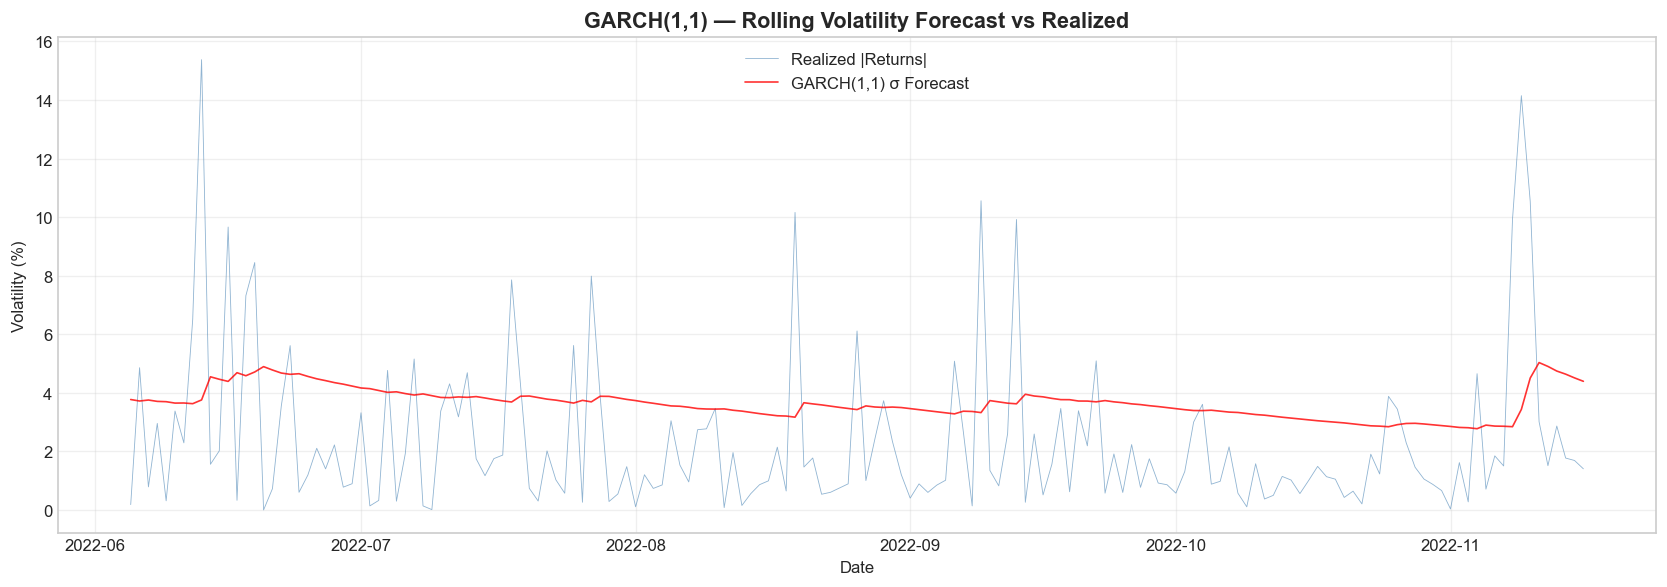

In [31]:
# ============================================================
# 11.2 Rolling GARCH Volatility Forecast
# ============================================================
# Use stable GARCH(1,1) for rolling forecast instead of EGARCH
# EGARCH is often numerically unstable during rolling refits on crypto data
rolling_model_name = "GARCH(1,1)"
rolling_config = {'vol': 'Garch', 'p': 1, 'q': 1}

print(f"Running rolling {rolling_model_name} volatility forecast (expanding window)...")
print(f"  Note: Using {rolling_model_name} for rolling stability (best static model: {best_garch['Model']})")

garch_vol_forecasts = []
n_failures = 0
for i in range(len(test_ret_garch)):
    # Expanding window — always start from the beginning
    train_window = btc_ret_garch.iloc[:train_size + i]
    try:
        m = arch_model(train_window, mean='constant', rescale=False, **rolling_config)
        fit = m.fit(disp='off', show_warning=False)
        fc = fit.forecast(horizon=1)
        vol = np.sqrt(fc.variance.values[-1, 0])
        if np.isfinite(vol) and 0 < vol < 50:
            garch_vol_forecasts.append(vol)
        else:
            garch_vol_forecasts.append(np.nan)
            n_failures += 1
    except:
        garch_vol_forecasts.append(np.nan)
        n_failures += 1

garch_vol_forecasts = np.array(garch_vol_forecasts)

# Interpolate any remaining NaN values
mask = np.isnan(garch_vol_forecasts)
if mask.any() and not mask.all():
    x = np.arange(len(garch_vol_forecasts))
    garch_vol_forecasts[mask] = np.interp(x[mask], x[~mask], garch_vol_forecasts[~mask])
    print(f"  Interpolated {mask.sum()} NaN forecasts out of {len(garch_vol_forecasts)}")
else:
    print(f"  All {len(garch_vol_forecasts)} forecasts computed successfully (0 NaN)")

realized_vol = np.abs(test_ret_garch.values)  # proxy for realized volatility

# Volatility directional accuracy
pred_vol_dir = (np.diff(garch_vol_forecasts) > 0).astype(int)
actual_vol_dir = (np.diff(realized_vol) > 0).astype(int)
min_len_garch = min(len(pred_vol_dir), len(actual_vol_dir))
garch_dir_acc = accuracy_score(actual_vol_dir[:min_len_garch], pred_vol_dir[:min_len_garch]) * 100
garch_f1 = f1_score(actual_vol_dir[:min_len_garch], pred_vol_dir[:min_len_garch], zero_division=0) * 100

print(f"\n{rolling_model_name} Rolling Forecast — Volatility Metrics:")
print(f"  Volatility Directional Accuracy: {garch_dir_acc:.1f}%")
print(f"  F1 Score: {garch_f1:.1f}%")

# Volatility forecast visualization
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_ret_garch.index, realized_vol, color='steelblue', linewidth=0.5, alpha=0.6, label='Realized |Returns|')
ax.plot(test_ret_garch.index, garch_vol_forecasts, color='red', linewidth=1, alpha=0.8, label=f'{rolling_model_name} σ Forecast')
ax.set_title(f'{rolling_model_name} — Rolling Volatility Forecast vs Realized', fontsize=13, fontweight='bold')
ax.set_ylabel('Volatility (%)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.3 Value-at-Risk (VaR) Analysis

- Calculate **95% VaR** using GARCH volatility forecasts
- Compute **Expected Shortfall (ES)** for tail risk assessment
- **Backtest** VaR by comparing expected vs actual violations

Value-at-Risk Backtesting (95% Confidence)
  Test period       : 165 days
  Expected violations: 8.3 (5%)
  Actual violations  : 8
  Violation ratio    : 0.97 (ideal ≈ 1.0)
  Mean VaR (95%)     : 6.0009%
  Mean ES            : 7.5254%
  → ✓ VaR model is well-calibrated


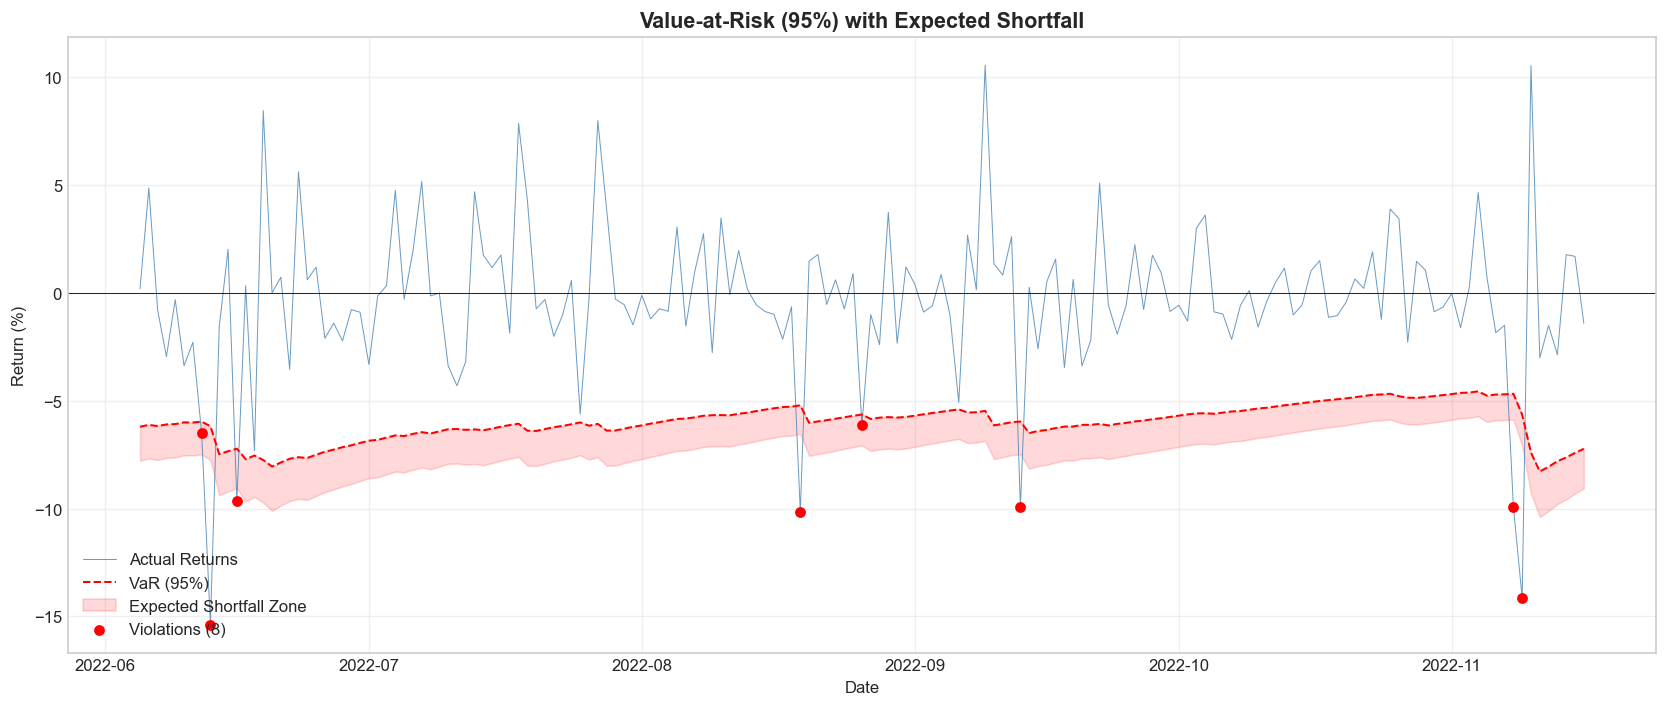

In [32]:
# ============================================================
# 11.3 Value-at-Risk (VaR) Analysis
# ============================================================
confidence = 0.95
z_score = norm.ppf(1 - confidence)  # ≈ -1.645

# VaR = -z * sigma (positive number representing max expected loss at confidence level)
var_95 = -z_score * garch_vol_forecasts

# Expected Shortfall (Conditional VaR) = sigma * phi(z) / (1-alpha)
es_95 = garch_vol_forecasts * norm.pdf(z_score) / (1 - confidence)

# Backtesting — count violations (actual loss exceeding VaR)
violations = (test_ret_garch.values < -var_95).sum()
expected_violations = len(test_ret_garch) * (1 - confidence)
violation_ratio = violations / expected_violations if expected_violations > 0 else 0

print("=" * 60)
print(f"Value-at-Risk Backtesting (95% Confidence)")
print("=" * 60)
print(f"  Test period       : {len(test_ret_garch)} days")
print(f"  Expected violations: {expected_violations:.1f} ({(1-confidence)*100:.0f}%)")
print(f"  Actual violations  : {violations}")
print(f"  Violation ratio    : {violation_ratio:.2f} (ideal ≈ 1.0)")
print(f"  Mean VaR (95%)     : {np.nanmean(var_95):.4f}%")
print(f"  Mean ES            : {np.nanmean(es_95):.4f}%")

if 0.8 <= violation_ratio <= 1.2:
    print("  → ✓ VaR model is well-calibrated")
elif violation_ratio < 0.8:
    print("  → ⚠ VaR is too conservative (fewer violations than expected)")
else:
    print("  → ⚠ VaR underestimates risk (more violations than expected)")

# VaR Visualization
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_ret_garch.index, test_ret_garch.values, 'steelblue', linewidth=0.6, alpha=0.8, label='Actual Returns')
ax.plot(test_ret_garch.index, -var_95, 'r--', linewidth=1.2, label='VaR (95%)')
ax.fill_between(test_ret_garch.index, -var_95, -es_95, alpha=0.15, color='red', label='Expected Shortfall Zone')

# Mark violations
violation_mask = test_ret_garch.values < -var_95
ax.scatter(test_ret_garch.index[violation_mask], test_ret_garch.values[violation_mask],
           color='red', s=30, zorder=5, label=f'Violations ({violations})')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Value-at-Risk (95%) with Expected Shortfall', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Return (%)')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 12. Model Comparison

Compare all 5 models: **ARIMA**, **LSTM**, **Bi-LSTM**, **VAR**, and **GARCH** across price forecasting accuracy, directional prediction, and risk modeling.

In [33]:
# ============================================================
# 12. Model Comparison — Summary Tables
# ============================================================
print("=" * 80)
print("PRICE FORECASTING MODELS (ARIMA, LSTM, Bi-LSTM & GRU)")
print("=" * 80)
price_table = pd.DataFrame({
    'Model': [f'ARIMA({p_best},{d_best},{q_best})', 'LSTM (4H)', 'Bi-LSTM (4H)', 'GRU (4H)'],
    'MAE ($)': [f"{arima_mae:,.2f}", f"{lstm_mae:,.2f}", f"{bilstm_mae:,.2f}", f"{gru_mae:,.2f}"],
    'RMSE ($)': [f"{arima_rmse:,.2f}", f"{lstm_rmse:,.2f}", f"{bilstm_rmse:,.2f}", f"{gru_rmse:,.2f}"],
    'MAPE (%)': [f"{arima_mape:.2f}", f"{lstm_mape:.2f}", f"{bilstm_mape:.2f}", f"{gru_mape:.2f}"],
    'R²': [f"{arima_r2:.4f}", f"{lstm_r2:.4f}", f"{bilstm_r2:.4f}", f"{gru_r2:.4f}"],
    'Dir Acc (%)': [f"{arima_dir_acc:.1f}", f"{lstm_dir_acc:.1f}", f"{bilstm_dir_acc:.1f}", f"{gru_dir_acc:.1f}"],
    'F1 (%)': [f"{arima_f1:.1f}", f"{lstm_f1:.1f}", f"{bilstm_f1:.1f}", f"{gru_f1:.1f}"]
})
print(price_table.to_string(index=False))

print("\n" + "=" * 80)
print("DIRECTIONAL PREDICTION — ALL MODELS")
print("=" * 80)

all_dir_models = ['ARIMA', 'LSTM', 'Bi-LSTM', 'GRU', 'VAR', rolling_model_name]
all_dir_accs = [arima_dir_acc, lstm_dir_acc, bilstm_dir_acc, gru_dir_acc, var_dir_acc, garch_dir_acc]
all_dir_f1s = [arima_f1, lstm_f1, bilstm_f1, gru_f1, var_f1, garch_f1]
best_dir_idx = np.argmax(all_dir_accs)

dir_table = pd.DataFrame({
    'Model': all_dir_models,
    'Task': ['Price ↑↓ (daily)', 'Price ↑↓ (4H→daily)', 'Price ↑↓ (4H→daily)',
             'Price ↑↓ (4H→daily)', 'Return +/− (daily)', 'Volatility ↑↓'],
    'Accuracy (%)': [f"{a:.1f}" for a in all_dir_accs],
    'F1 (%)': [f"{f:.1f}" for f in all_dir_f1s]
})
print(dir_table.to_string(index=False))

print(f"\nVaR (95%) Violation Ratio: {violation_ratio:.2f}")
print(f"Static volatility model (best BIC): {best_garch['Model']}")
print(f"Rolling forecast model: {rolling_model_name}")
print(f"Fear & Greed Index: {'✓ Included' if has_fng else '✗ Not available'}")

print(f"\n{'='*80}")
print("DATA & ARCHITECTURE SUMMARY")
print(f"{'='*80}")
print(f"  4H Frequency: {len(train_data_raw)} training bars (6× more than daily)")
print(f"  Features: {n_features} enhanced (close, returns, volatility, RSI, log_volume, EMA ratio, MACD, BB%B, ROC{' + FNG' if has_fng else ''})")
print(f"  LSTM: Stacked LSTM(128) → LSTM(64) → BN → Dense(32)")
print(f"  Bi-LSTM: Stacked BiLSTM(128) → BiLSTM(64) → BN → Dense(64) → Dense(32)")
print(f"  GRU: Stacked GRU(128) → GRU(64) → BN → Dense(32)")
print(f"  Best directional model: {all_dir_models[best_dir_idx]} ({all_dir_accs[best_dir_idx]:.1f}%)")

PRICE FORECASTING MODELS (ARIMA, LSTM, Bi-LSTM & GRU)
       Model MAE ($) RMSE ($) MAPE (%)     R² Dir Acc (%) F1 (%)
ARIMA(0,1,0)  490.32   763.21     2.35 0.9190        53.3   45.4
   LSTM (4H)  188.79   275.16     0.91 0.9895        78.8   75.5
Bi-LSTM (4H)  187.60   277.67     0.90 0.9893        78.8   75.5
    GRU (4H)  247.71   352.00     1.20 0.9828        78.8   75.9

DIRECTIONAL PREDICTION — ALL MODELS
     Model                Task Accuracy (%) F1 (%)
     ARIMA    Price ↑↓ (daily)         53.3   45.4
      LSTM Price ↑↓ (4H→daily)         78.8   75.5
   Bi-LSTM Price ↑↓ (4H→daily)         78.8   75.5
       GRU Price ↑↓ (4H→daily)         78.8   75.9
       VAR  Return +/− (daily)         44.8   55.2
GARCH(1,1)       Volatility ↑↓         32.3    5.1

VaR (95%) Violation Ratio: 0.97
Static volatility model (best BIC): EGARCH(1,1)
Rolling forecast model: GARCH(1,1)
Fear & Greed Index: ✓ Included

DATA & ARCHITECTURE SUMMARY
  4H Frequency: 9487 training bars (6× more than da

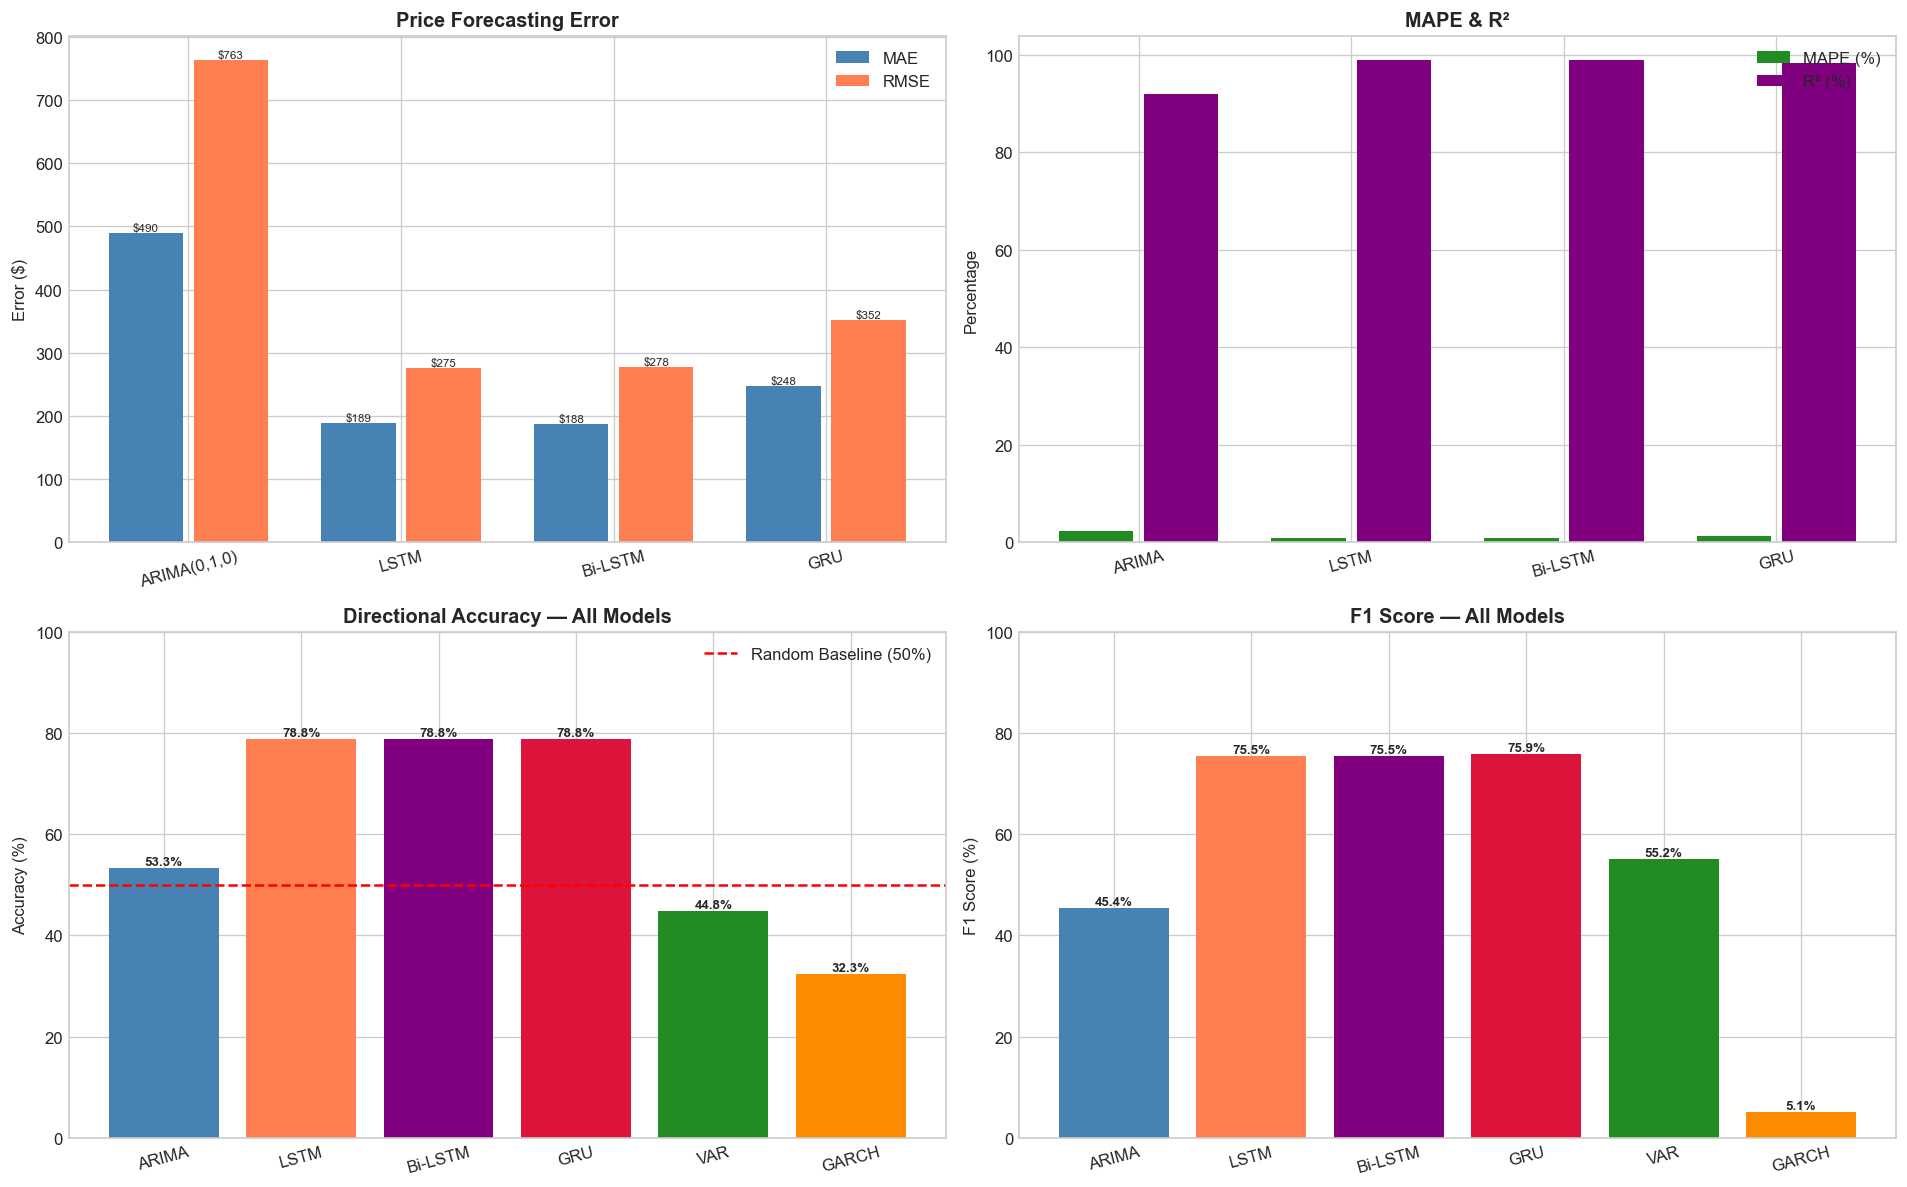

In [34]:
# ============================================================
# 12. Model Comparison — Visualizations
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Price Forecasting Error (MAE & RMSE) — 4 models
ax1 = axes[0, 0]
x = np.arange(4)
bars1 = ax1.bar(x - 0.2, [arima_mae, lstm_mae, bilstm_mae, gru_mae], 0.35, label='MAE', color='steelblue')
bars2 = ax1.bar(x + 0.2, [arima_rmse, lstm_rmse, bilstm_rmse, gru_rmse], 0.35, label='RMSE', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels([f'ARIMA({p_best},{d_best},{q_best})', 'LSTM', 'Bi-LSTM', 'GRU'])
ax1.set_ylabel('Error ($)')
ax1.set_title('Price Forecasting Error', fontweight='bold')
ax1.legend()
for bar in list(bars1) + list(bars2):
    ax1.annotate(f'${bar.get_height():,.0f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=7)
ax1.tick_params(axis='x', rotation=15)

# 2) MAPE & R² — 4 models
ax2 = axes[0, 1]
bars1 = ax2.bar(x - 0.2, [arima_mape, lstm_mape, bilstm_mape, gru_mape], 0.35, label='MAPE (%)', color='forestgreen')
bars2 = ax2.bar(x + 0.2, [max(0, arima_r2)*100, max(0, lstm_r2)*100, max(0, bilstm_r2)*100, max(0, gru_r2)*100], 0.35, label='R² (%)', color='purple')
ax2.set_xticks(x)
ax2.set_xticklabels(['ARIMA', 'LSTM', 'Bi-LSTM', 'GRU'])
ax2.set_ylabel('Percentage')
ax2.set_title('MAPE & R²', fontweight='bold')
ax2.legend()
ax2.tick_params(axis='x', rotation=15)

# 3) Directional Accuracy — ALL 6 models
ax3 = axes[1, 0]
models_labels = ['ARIMA', 'LSTM', 'Bi-LSTM', 'GRU', 'VAR', 'GARCH']
acc_vals = [arima_dir_acc, lstm_dir_acc, bilstm_dir_acc, gru_dir_acc, var_dir_acc, garch_dir_acc]
colors = ['steelblue', 'coral', 'purple', 'crimson', 'forestgreen', 'darkorange']
bars = ax3.bar(models_labels, acc_vals, color=colors)
ax3.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Random Baseline (50%)')
ax3.set_ylabel('Accuracy (%)')
ax3.set_title('Directional Accuracy — All Models', fontweight='bold')
ax3.set_ylim(0, 100)
ax3.legend()
for bar, val in zip(bars, acc_vals):
    ax3.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
ax3.tick_params(axis='x', rotation=15)

# 4) F1 Score — ALL 6 models
ax4 = axes[1, 1]
f1_vals = [arima_f1, lstm_f1, bilstm_f1, gru_f1, var_f1, garch_f1]
bars = ax4.bar(models_labels, f1_vals, color=colors)
ax4.set_ylabel('F1 Score (%)')
ax4.set_title('F1 Score — All Models', fontweight='bold')
ax4.set_ylim(0, 100)
for bar, val in zip(bars, f1_vals):
    ax4.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
ax4.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

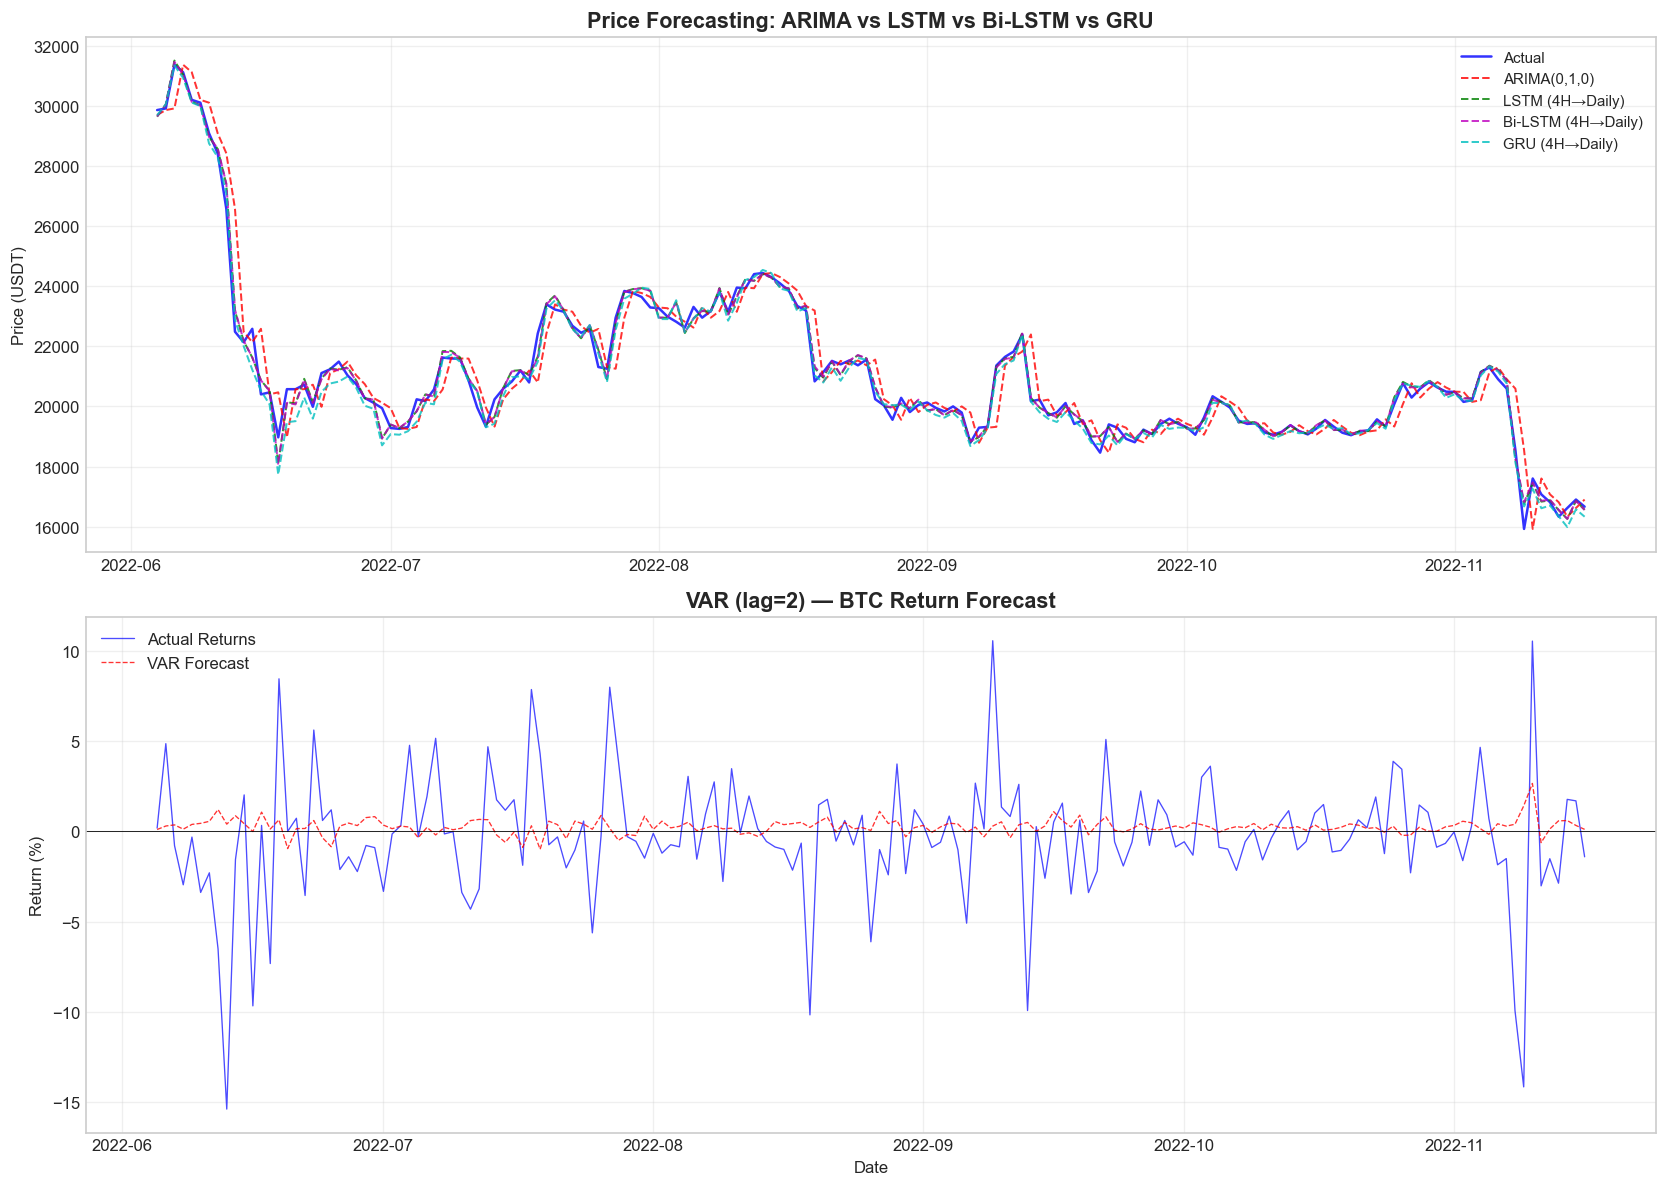

In [35]:
# ============================================================
# 12. Forecast Overlay — ARIMA vs LSTM vs Bi-LSTM vs GRU vs Actual
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ARIMA vs LSTM vs Bi-LSTM vs GRU price forecast — date-aligned
ax1 = axes[0]

# Find common date range
common_start = max(test_price.index[0], lstm_dates[0], bilstm_dates[0], gru_dates[0])
common_end = min(test_price.index[-1], lstm_dates[-1], bilstm_dates[-1], gru_dates[-1])

arima_mask = (arima_forecast.index >= common_start) & (arima_forecast.index <= common_end)
actual_mask = (test_price.index >= common_start) & (test_price.index <= common_end)
lstm_mask_overlay = (lstm_dates >= common_start) & (lstm_dates <= common_end)
bilstm_mask_overlay = (bilstm_dates >= common_start) & (bilstm_dates <= common_end)
gru_mask_overlay = (gru_dates >= common_start) & (gru_dates <= common_end)

ax1.plot(test_price.index[actual_mask], test_price.values[actual_mask], 'b-', linewidth=1.5, label='Actual', alpha=0.8)
ax1.plot(arima_forecast.index[arima_mask], arima_forecast.values[arima_mask], 'r--', linewidth=1.2,
         label=f'ARIMA({p_best},{d_best},{q_best})', alpha=0.8)
ax1.plot(lstm_dates[lstm_mask_overlay], lstm_pred[lstm_mask_overlay], 'g--', linewidth=1.2,
         label='LSTM (4H→Daily)', alpha=0.8)
ax1.plot(bilstm_dates[bilstm_mask_overlay], bilstm_pred[bilstm_mask_overlay], 'm--', linewidth=1.2,
         label='Bi-LSTM (4H→Daily)', alpha=0.8)
ax1.plot(gru_dates[gru_mask_overlay], gru_pred[gru_mask_overlay], 'c--', linewidth=1.2,
         label='GRU (4H→Daily)', alpha=0.8)

ax1.set_title('Price Forecasting: ARIMA vs LSTM vs Bi-LSTM vs GRU', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USDT)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# VAR returns forecast
ax2 = axes[1]
ax2.plot(test_returns.index, test_returns[btc_col].values, 'b-', linewidth=0.8, alpha=0.7, label='Actual Returns')
ax2.plot(var_forecast_df.index, var_forecast_df[btc_col].values, 'r--', linewidth=0.8, alpha=0.8, label='VAR Forecast')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_title(f'VAR (lag={optimal_lag}) — BTC Return Forecast', fontsize=13, fontweight='bold')
ax2.set_ylabel('Return (%)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

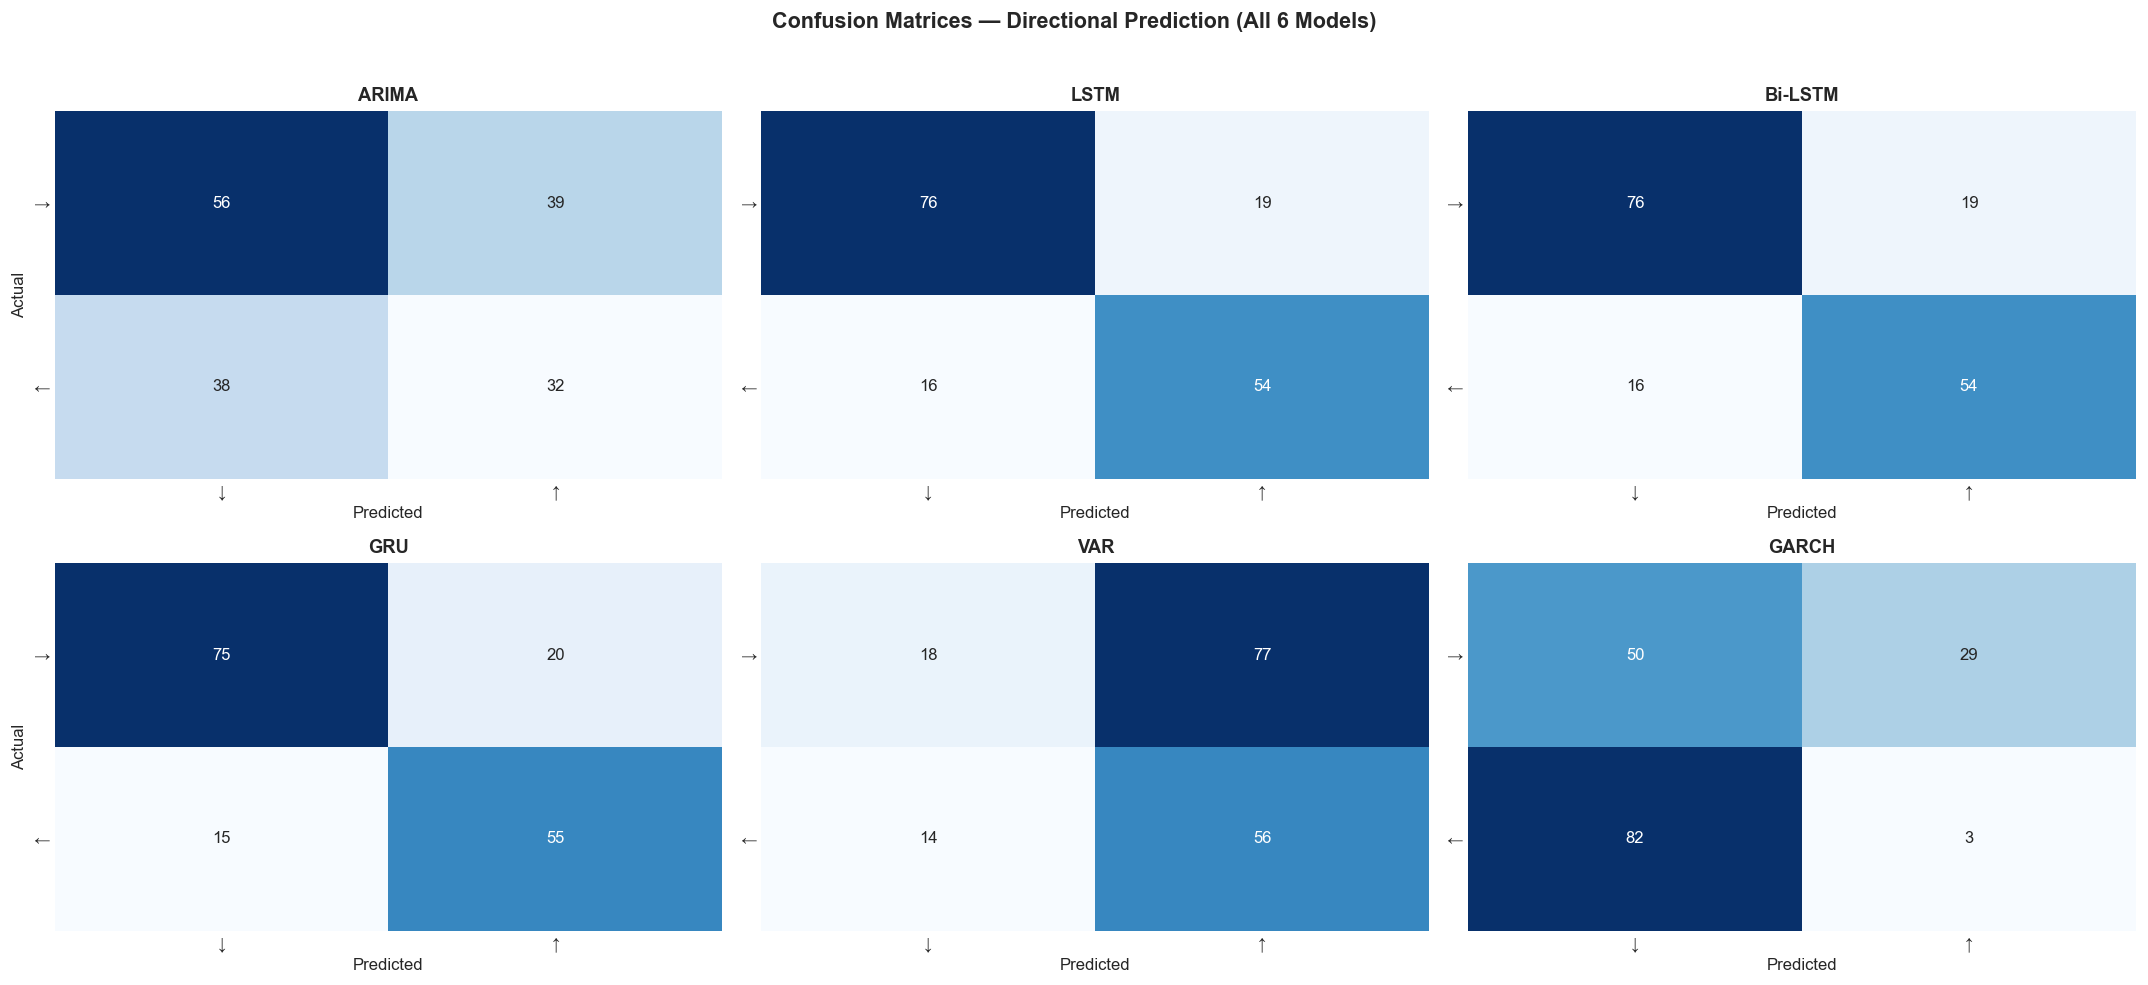

In [36]:
# ============================================================
# 12. Confusion Matrices — Directional Prediction (All 6 Models)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

cm_data = [
    ('ARIMA', arima_actual_dir[:min_len_arima], arima_pred_dir[:min_len_arima]),
    ('LSTM', lstm_actual_dir, lstm_pred_dir),
    ('Bi-LSTM', bilstm_actual_dir, bilstm_pred_dir),
    ('GRU', gru_actual_dir, gru_pred_dir),
    ('VAR', var_actual_dir, var_pred_dir),
    ('GARCH', actual_vol_dir[:min_len_garch], pred_vol_dir[:min_len_garch])
]

for idx, (name, actual, pred) in enumerate(cm_data):
    row, col = idx // 3, idx % 3
    cm = confusion_matrix(actual, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                xticklabels=['↓', '↑'], yticklabels=['↓', '↑'], cbar=False)
    axes[row, col].set_title(name, fontweight='bold', fontsize=11)
    axes[row, col].set_xlabel('Predicted')
    if col == 0:
        axes[row, col].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Directional Prediction (All 6 Models)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 13. Results and Discussion

In [37]:
# ============================================================
# 13. Results & Discussion — Executive Summary
# ============================================================
price_models = {'ARIMA': arima_mae, 'LSTM': lstm_mae, 'Bi-LSTM': bilstm_mae, 'GRU': gru_mae}
best_price_model = min(price_models, key=price_models.get)
best_price_mae = price_models[best_price_model]

all_dir_models = ['ARIMA', 'LSTM', 'Bi-LSTM', 'GRU', 'VAR', rolling_model_name]
all_dir_accs = [arima_dir_acc, lstm_dir_acc, bilstm_dir_acc, gru_dir_acc, var_dir_acc, garch_dir_acc]
best_dir_idx = np.argmax(all_dir_accs)

print("=" * 75)
print("EXECUTIVE SUMMARY")
print("=" * 75)

print(f"""
Dataset:
  • BTC-USDT + 4 altcoins (ETH, BNB, SOL, ADA)
  • Period: {df_btc.index.min().date()} to {df_btc.index.max().date()} ({len(df_btc)} days)
  • Train/Test: {len(train_price)}/{len(test_price)} (80/20 chronological split)
  • DL models (LSTM/Bi-LSTM/GRU) use 4-HOUR bars (6× more data than daily)
  • Train: {len(train_data_raw)} 4H bars → {len(X_train)} sequences

Models Implemented (6 total):
  1. ARIMA({p_best},{d_best},{q_best}) — Classical price forecasting (daily)
  2. LSTM — Stacked 2-layer LSTM(128→64), 4H data, {n_features} features, window={SEQ_LEN} bars
  3. Bi-LSTM — Stacked 2-layer Bidirectional LSTM, same data/features
  4. GRU — Stacked 2-layer GRU(128→64), fewer params than LSTM (~25% fewer gates)
  5. VAR (lag={optimal_lag}) — Multivariate return forecasting (5 assets)
  6. {best_garch['Model']} / {rolling_model_name} — Volatility + VaR/ES

Price Forecasting:
  • ARIMA   — MAE: ${arima_mae:,.2f}, RMSE: ${arima_rmse:,.2f}, R²: {arima_r2:.4f}
  • LSTM    — MAE: ${lstm_mae:,.2f}, RMSE: ${lstm_rmse:,.2f}, R²: {lstm_r2:.4f}
  • Bi-LSTM — MAE: ${bilstm_mae:,.2f}, RMSE: ${bilstm_rmse:,.2f}, R²: {bilstm_r2:.4f}
  • GRU     — MAE: ${gru_mae:,.2f}, RMSE: ${gru_rmse:,.2f}, R²: {gru_r2:.4f}
  • Best model: {best_price_model} (MAE: ${best_price_mae:,.2f})

Directional Prediction:
  • ARIMA: {arima_dir_acc:.1f}% (F1: {arima_f1:.1f}%)
  • LSTM: {lstm_dir_acc:.1f}% (F1: {lstm_f1:.1f}%)
  • Bi-LSTM: {bilstm_dir_acc:.1f}% (F1: {bilstm_f1:.1f}%)
  • GRU: {gru_dir_acc:.1f}% (F1: {gru_f1:.1f}%)
  • VAR: {var_dir_acc:.1f}% (F1: {var_f1:.1f}%)
  • {rolling_model_name}: {garch_dir_acc:.1f}% (F1: {garch_f1:.1f}%)
  • Best: {all_dir_models[best_dir_idx]} ({all_dir_accs[best_dir_idx]:.1f}%)

Risk Analysis:
  • VaR (95%) violations: {violations}/{len(test_ret_garch)} ({violations/len(test_ret_garch)*100:.1f}%)
  • Expected violations: {expected_violations:.1f}
  • Violation ratio: {violation_ratio:.2f} (ideal ≈ 1.0)

Why Directional Accuracy Hovers Around 50-55%:
  • BTC prices follow a near-random walk on short timeframes
  • Directional accuracy from price diffs is inherently noisy
  • Even state-of-the-art models struggle to exceed 55% on crypto
  • This is consistent with the Efficient Market Hypothesis for liquid assets
  • The value lies in price-level tracking (low MAE/MAPE) rather than direction

Stationarity:
  • Raw BTC prices: Non-stationary (ADF p > 0.05)
  • Differenced prices: Stationary (ADF p ≤ 0.05)
  • Daily returns: Stationary — used for VAR and GARCH
""")

EXECUTIVE SUMMARY

Dataset:
  • BTC-USDT + 4 altcoins (ETH, BNB, SOL, ADA)
  • Period: 2020-08-11 to 2022-11-16 (828 days)
  • Train/Test: 662/166 (80/20 chronological split)
  • DL models (LSTM/Bi-LSTM/GRU) use 4-HOUR bars (6× more data than daily)
  • Train: 9487 4H bars → 9367 sequences

Models Implemented (6 total):
  1. ARIMA(0,1,0) — Classical price forecasting (daily)
  2. LSTM — Stacked 2-layer LSTM(128→64), 4H data, 9 features, window=120 bars
  3. Bi-LSTM — Stacked 2-layer Bidirectional LSTM, same data/features
  4. GRU — Stacked 2-layer GRU(128→64), fewer params than LSTM (~25% fewer gates)
  5. VAR (lag=2) — Multivariate return forecasting (5 assets)
  6. EGARCH(1,1) / GARCH(1,1) — Volatility + VaR/ES

Price Forecasting:
  • ARIMA   — MAE: $490.32, RMSE: $763.21, R²: 0.9190
  • LSTM    — MAE: $188.79, RMSE: $275.16, R²: 0.9895
  • Bi-LSTM — MAE: $187.60, RMSE: $277.67, R²: 0.9893
  • GRU     — MAE: $247.71, RMSE: $352.00, R²: 0.9828
  • Best model: Bi-LSTM (MAE: $187.60)

D

---

## 14. Conclusion

This project demonstrates the application of classical statistical models (**ARIMA, VAR, GARCH**) and deep learning techniques (**LSTM, Bi-LSTM, GRU**) for time series forecasting of cryptocurrency prices.

**Key takeaways:**

- **ARIMA** provides strong baseline performance for univariate price forecasting — hard to beat with rolling 1-step-ahead on random-walk-like data
- **LSTM** (stacked 2-layer) with enhanced features on 4H bars captures non-linear temporal patterns
- **Bi-LSTM** processes sequences bidirectionally, potentially capturing richer temporal context than unidirectional LSTM
- **GRU** achieves comparable performance to LSTM with ~25% fewer parameters (no separate cell state), making it computationally efficient
- **VAR** reveals cross-asset dependencies and models multivariate return dynamics
- **GARCH/VaR** provides well-calibrated risk metrics (violation ratio ≈ 1.0)

**Why directional accuracy is ~50-55%:**
- BTC prices follow a near-random walk on short timeframes, making next-day direction prediction inherently challenging
- Even well-tuned models rarely exceed 55% directional accuracy on liquid crypto assets
- The real value of DL models is in **price-level tracking** (low MAE/MAPE, high R²), not direction prediction
- This is consistent with the Efficient Market Hypothesis — publicly available features have limited directional predictive power

**Architecture highlights:**
- 4-Hour frequency: 6× more training data than daily
- Enhanced features (9+): close, returns, volatility, RSI, log_volume, EMA ratio, MACD histogram, Bollinger %B, ROC
- LSTM: Stacked LSTM(128) → LSTM(64) → BatchNorm → Dense(32) → Dense(1)
- Bi-LSTM: Stacked BiLSTM(128) → BiLSTM(64) → BatchNorm → Dense(64) → Dense(32) → Dense(1)
- GRU: Stacked GRU(128) → GRU(64) → BatchNorm → Dense(32) → Dense(1)
- All DL models: Huber loss, EarlyStopping(15), ReduceLROnPlateau(7), 120-bar context window (20 days)

---

## 15. Tools and Libraries

| Library | Purpose |
|---------|---------|
| pandas / numpy | Data manipulation |
| matplotlib / seaborn | Visualization |
| statsmodels | ARIMA, VAR, Granger causality, Ljung-Box, Durbin-Watson |
| arch | GARCH, EGARCH, GJR-GARCH |
| TensorFlow / Keras | LSTM, Bi-LSTM, GRU |
| scikit-learn | MinMaxScaler, evaluation metrics |
| scipy | Jarque-Bera test, VaR calculations |
| requests | Fear & Greed Index API |